# Δεύτερο Σκέλος διπλωματικής

Η παρακάτω υλοποίηση αφορά στη δημιουργία ενός προγνωστικού μοντέλου για την αποχώρηση προσωπικού, με βασικό στόχο την αξιοποίηση ιστορικών δεδομένων για στρατηγική συμβολή. Το σύνολο δεδομένων που χρησιμοποιήθηκε στην ακόλουθη μελέτη είναι το [IBM Human analytics Dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset?select=WA_Fn-UseC_-HR-Employee-Attrition.csv), παραχωρημένα από την ιστοσελίδα Kaggle.

Οι πρακτικές που θα εφαρμοστούν περιλαμβάνουν EDA (Exploratory Data Analysis) & Data Wrangling, Machine Learning για Classification και βελτιστοποίηση των τελικών μοντέλων για μέγιστη προγνωστική ακρίβεια.

In [92]:
#all libraries used by this part
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install imbalanced-learn
# !pip install scikit-optimize
# !pip install xgboost
# !pip install lightgbm

In [1]:
#fundamental libraries for this analysis
import pandas as pd
import numpy as np

#loading the dataset
ibm_ds = pd.read_csv('C:/Users/chris/Desktop/Masters Degree/THESIS AND PROPOSAL/datasets/IBM-HR-Employee-Attrition.csv', delimiter=',')
#showing info of the dataset
print(ibm_ds.info())
print(ibm_ds.head())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [2]:
#NaNs check
print(f"NaNs in the dataset: \n{ibm_ds.isnull().sum()}")
#duplicates check
print(f"Duplicate lines: {ibm_ds.duplicated().sum()}")

NaNs in the dataset: 
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole

# Numerical Columns:

-Age: Ηλικία του εργαζόμενου.

-DailyRate, HourlyRate, MonthlyRate: Διαφορετικοί δείκτες αμοιβής του εργαζόμενου.

-DistanceFromHome: Η απόσταση από το σπίτι στη δουλειά

-MonthlyIncome: Ο μηνιαίος μισθός

-PercentSalaryHike: Το ποσοστό της τελευταίας αύξησης μισθού.

-StockOptionLevel: Το επίπεδο των μετοχών/δικαιωμάτων που κατέχει ο εργαζόμενος (0
έως 3).

-JobLevel: Το ιεραρχικό επίπεδο στη θέση εργασίας (1 έως 5).

-NumCompaniesWorked: Ο αριθμός των προηγούμενων εταιρειών στις οποίες έχει εργαστεί ο
 υπάλληλος.
-TotalWorkingYears: Συνολικά έτη προϋπηρεσίας.

-TrainingTimesLastYear: Πόσες φορές εκπαιδεύτηκε πέρυσι ο εργαζόμενος.

-TotalWorkingYears: Τα συνολικά χρόνια εργασίας του εργαζόμενου.

-YearsAtCompany: Έτη στην τρέχουσα εταιρεία.

-YearsInCurrentRole: Έτη στον τρέχοντα ρόλο.

-YearsSinceLastPromotion: Έτη που πέρασαν από την τελευταία προαγωγή.

-YearsWithCurrManager: Έτη συνεργασίας με τον τρέχοντα manager.

-EmployeeCount: Έχει πάντα την τιμή 1.

-EmployeeNumber: Το ID εργαζομένου.

-StandardHours: Οι ώρες εργασίας ανά 15ήμερο (που είναι πάντα 80)

Category of Age
Mean : 36.923809523809524
Median : 36.0
Standard Deviation : 9.135373489136732
Minimum value : 18.0
Maximum value : 60.0



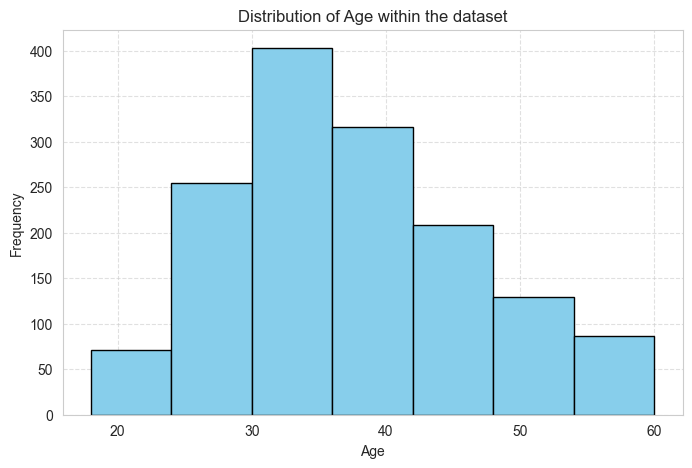

Category of DailyRate
Mean : 802.4857142857143
Median : 802.0
Standard Deviation : 403.50909994352816
Minimum value : 102.0
Maximum value : 1499.0



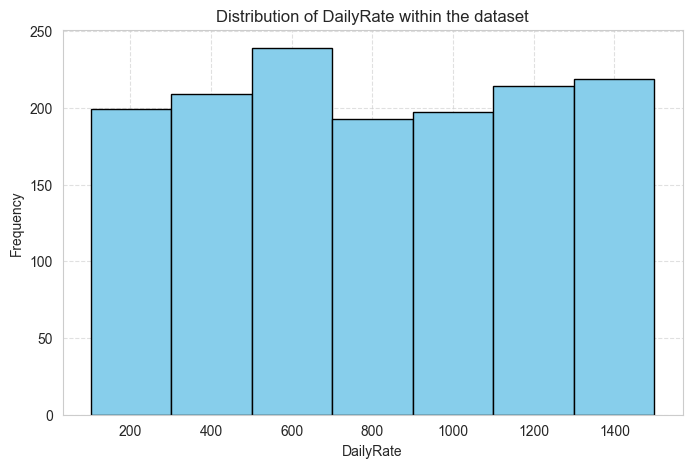

Category of HourlyRate
Mean : 65.89115646258503
Median : 66.0
Standard Deviation : 20.329427593996165
Minimum value : 30.0
Maximum value : 100.0



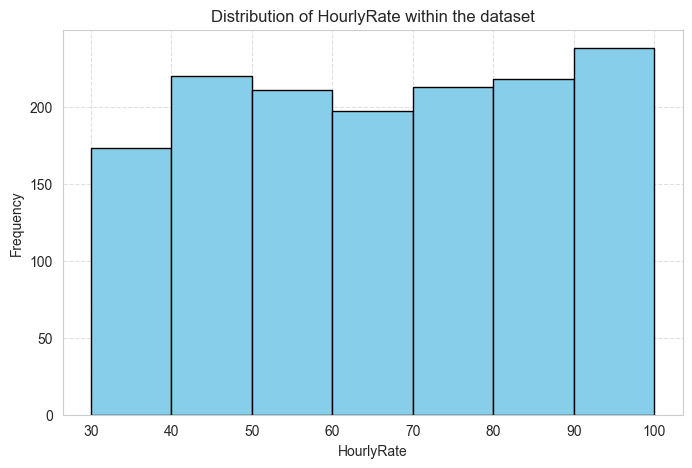

Category of MonthlyRate
Mean : 14313.103401360544
Median : 14235.5
Standard Deviation : 7117.786044059976
Minimum value : 2094.0
Maximum value : 26999.0



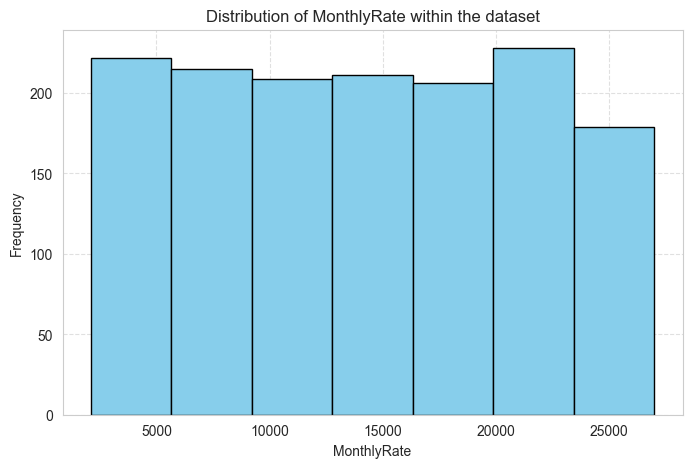

Category of DistanceFromHome
Mean : 9.19251700680272
Median : 7.0
Standard Deviation : 8.106864435666074
Minimum value : 1.0
Maximum value : 29.0



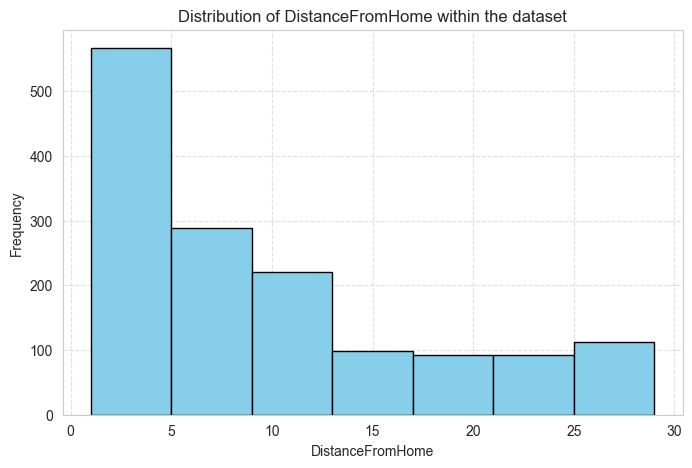

Category of MonthlyIncome
Mean : 6502.931292517007
Median : 4919.0
Standard Deviation : 4707.956783097994
Minimum value : 1009.0
Maximum value : 19999.0



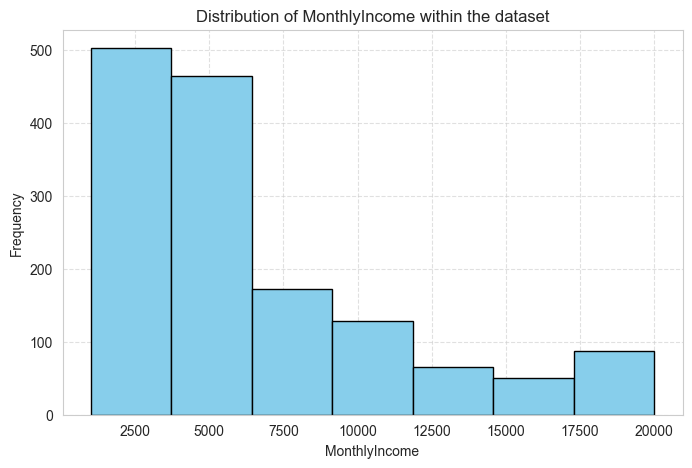

Category of PercentSalaryHike
Mean : 15.209523809523809
Median : 14.0
Standard Deviation : 3.6599377165396407
Minimum value : 11.0
Maximum value : 25.0



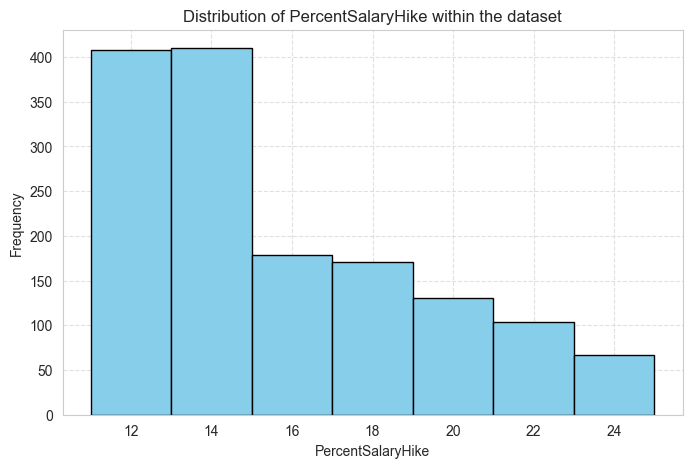

Category of NumCompaniesWorked
Mean : 2.6931972789115646
Median : 2.0
Standard Deviation : 2.498009006070747
Minimum value : 0.0
Maximum value : 9.0



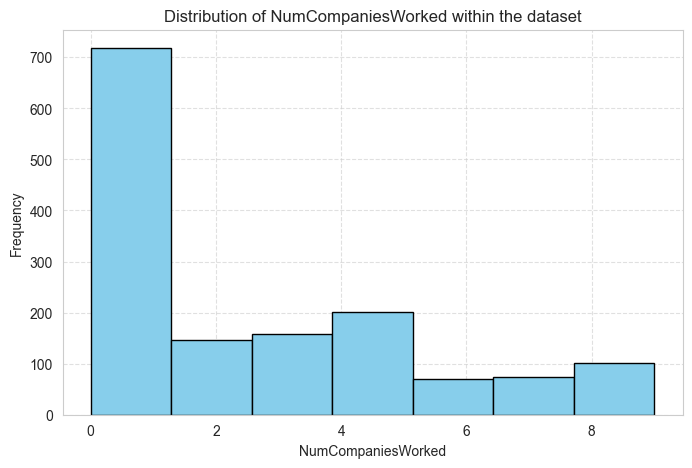

Category of TrainingTimesLastYear
Mean : 2.7993197278911564
Median : 3.0
Standard Deviation : 1.2892706207958455
Minimum value : 0.0
Maximum value : 6.0



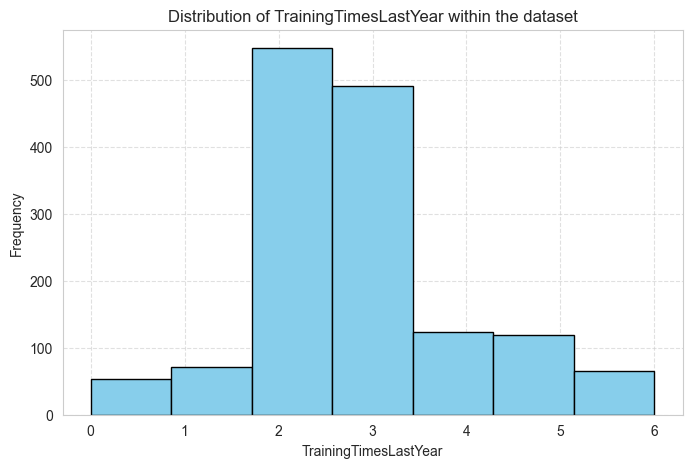

Category of YearsAtCompany
Mean : 7.0081632653061225
Median : 5.0
Standard Deviation : 6.126525152403569
Minimum value : 0.0
Maximum value : 40.0



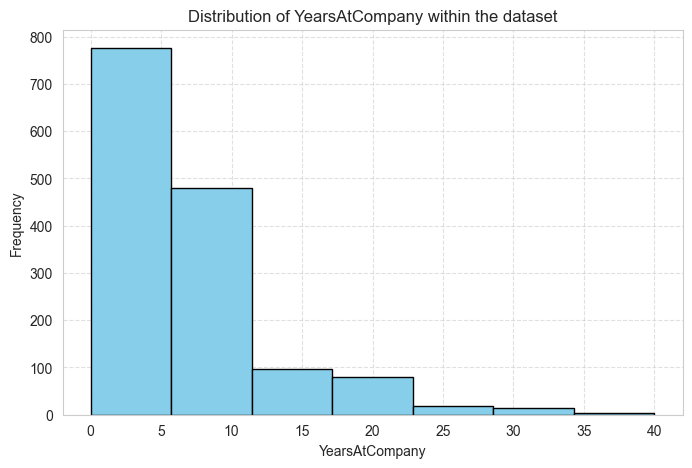

Category of YearsInCurrentRole
Mean : 4.229251700680272
Median : 3.0
Standard Deviation : 3.623137034670628
Minimum value : 0.0
Maximum value : 18.0



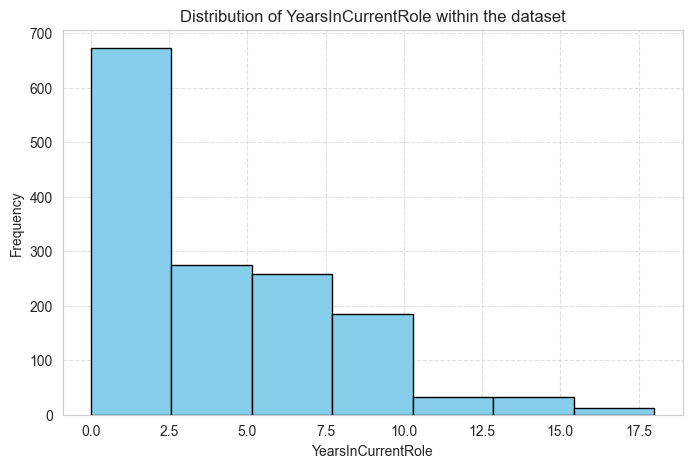

Category of YearsSinceLastPromotion
Mean : 2.1877551020408164
Median : 1.0
Standard Deviation : 3.222430279137967
Minimum value : 0.0
Maximum value : 15.0



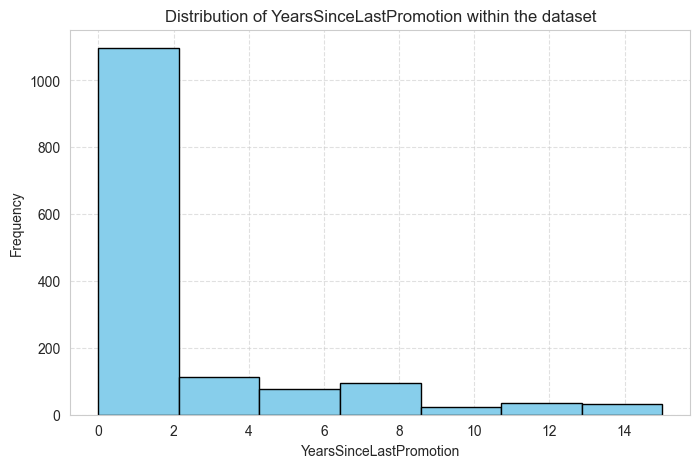

Category of YearsWithCurrManager
Mean : 4.12312925170068
Median : 3.0
Standard Deviation : 3.5681361205404376
Minimum value : 0.0
Maximum value : 17.0



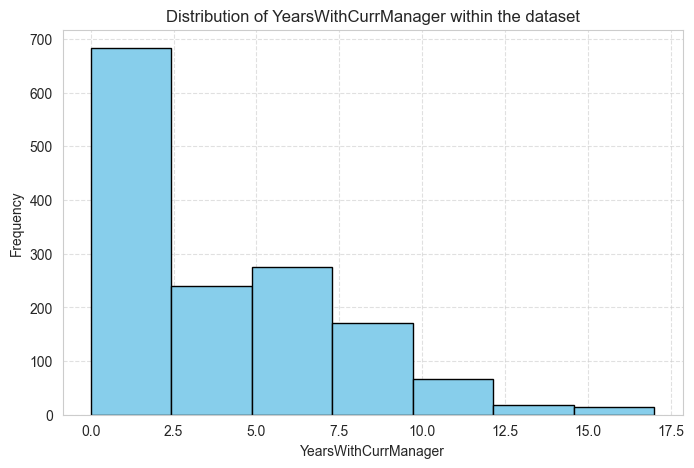

Category of TotalWorkingYears
Mean : 11.279591836734694
Median : 10.0
Standard Deviation : 7.780781675514997
Minimum value : 0.0
Maximum value : 40.0



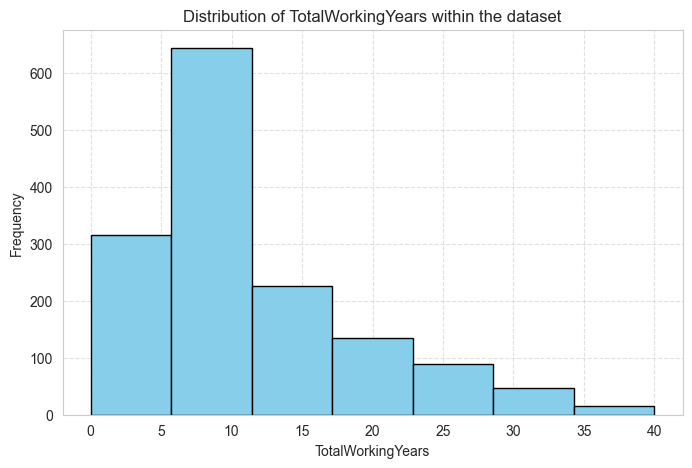

In [3]:
import matplotlib.pyplot as plt

#putting all the numeric columns shown by the previous block in a list, to later on show relevant info about them
numerical_columns = ['Age',
                     'DailyRate',
                     'HourlyRate',
                     'MonthlyRate',
                     'DistanceFromHome',
                     'MonthlyIncome',
                     'PercentSalaryHike',
                     'NumCompaniesWorked',
                     'TrainingTimesLastYear',
                     'YearsAtCompany',
                     'YearsInCurrentRole',
                     'YearsSinceLastPromotion',
                     'YearsWithCurrManager',
                     'TotalWorkingYears'
                    ]
#looping per numerical column
for column in numerical_columns:
    #all numeric columns will be treated as numbers with the code below
    ibm_ds[column] = np.float64(ibm_ds[column])

    #showing useful information per column (Mean/Median, SD, Min/Max)
    print("Category of",column)
    print("Mean :",ibm_ds[column].mean())
    print("Median :",ibm_ds[column].median())
    print("Standard Deviation :",ibm_ds[column].std())
    print("Minimum value :",ibm_ds[column].min())
    print("Maximum value :",ibm_ds[column].max())
    print("")

    #creating the plots accordingly, chosing 7 bins for visibility
    plt.figure(figsize=(8,5))
    plt.hist(ibm_ds[column], bins=7, color="skyblue", edgecolor="black")
    plt.title("Distribution of "+column+" within the dataset")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


W# Categorical columns

-Attrition: Η μεταβλητή-στόχος του συνόλου. Παίρνει μόνο Yes ή No.

-BusinessTravel: Συχνότητα επαγγελματικών ταξιδιών (Travel_Rarely, Travel_Frequently, Non-Travel).

-Department: Το τμήμα που εργάζεται (Sales, Research & Development, Human Resources).

-EducationField: Το αντικείμενο σπουδών (Life Sciences, Medical, Marketing, Technical Degree, Human Resources, Other).

-Gender: Φύλο (Male, Female).

-JobRole: Ο συγκεκριμένος ρόλος (Sales Executive, Research Scientist, Laboratory Technician, Manufacturing Director, Healthcare Representative, Manager, Sales Representative, Research Director, Human Resources).

-MaritalStatus: Οικογενειακή κατάσταση (Single, Married, Divorced).

-OverTime: Αν εργάζεται υπερωρίες (Yes, No).

-Over18: Είναι πάντα Υ (Υ/Ν).

-Education: Επίπεδο εκπαίδευσης (1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor').

-EnvironmentSatisfaction: Ικανοποίηση από το εργασιακό περιβάλλον (1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High').

-JobInvolvement: Βαθμός εμπλοκής/δέσμευσης στην εργασία (1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High').

-JobSatisfaction: Ικανοποίηση από την εργασία (1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High').

-PerformanceRating: Αξιολόγηση απόδοσης (3: 'Excellent', 4: 'Outstanding'.

-RelationshipSatisfaction: Ικανοποίηση από τις εργασιακές σχέσεις (1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High').

-WorkLifeBalance: Ισορροπία επαγγελματικής και προσωπικής ζωής (1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best').

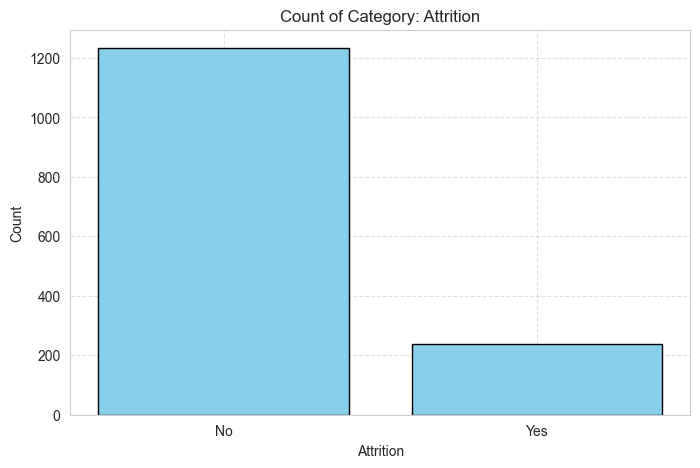

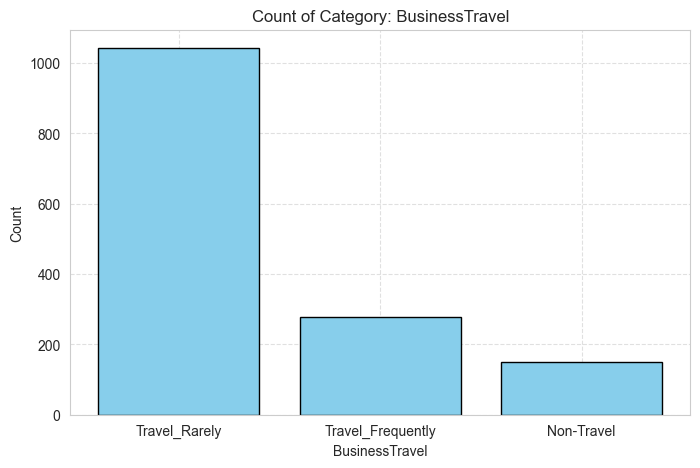

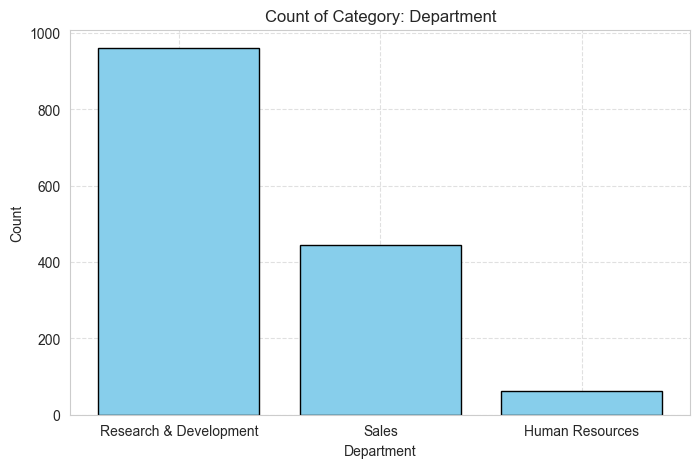

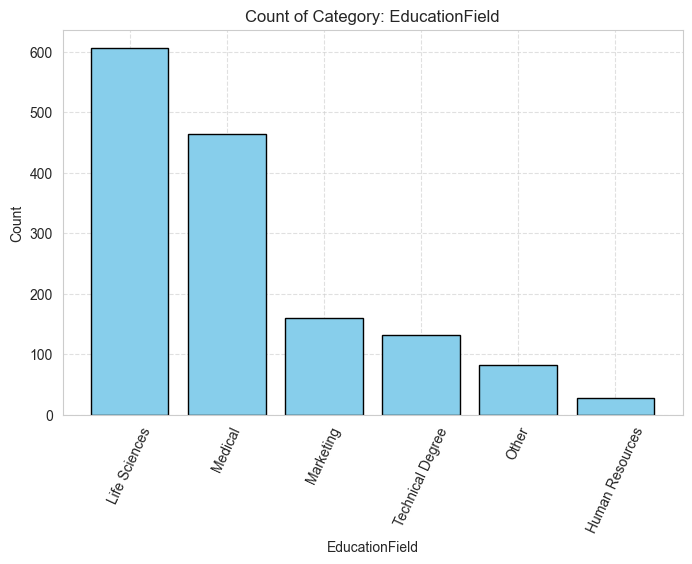

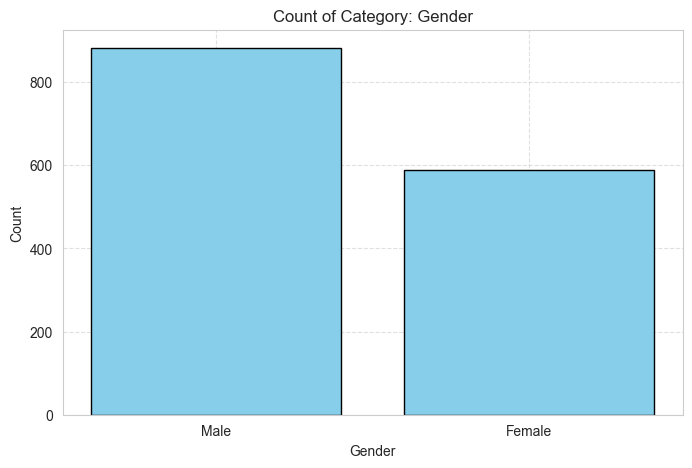

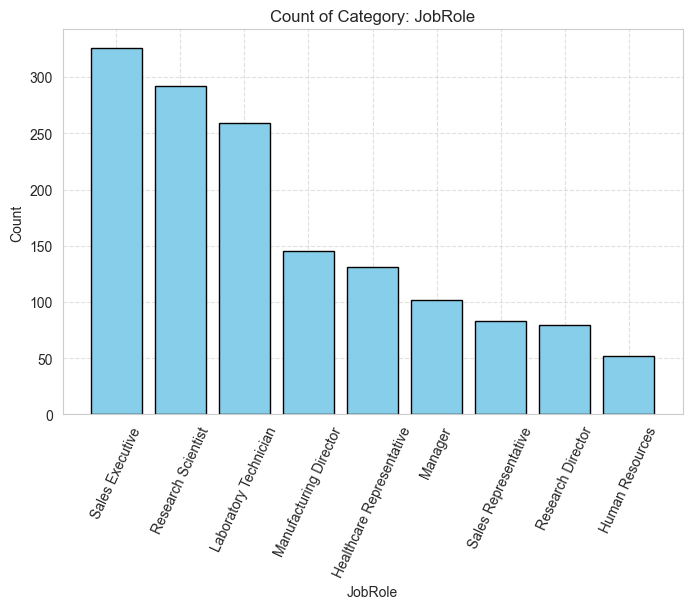

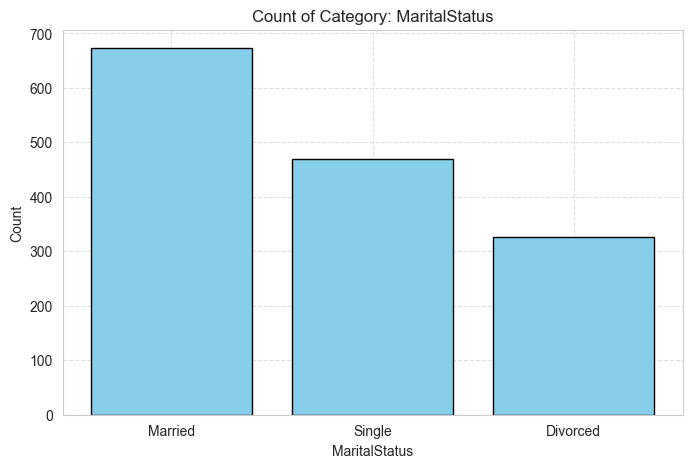

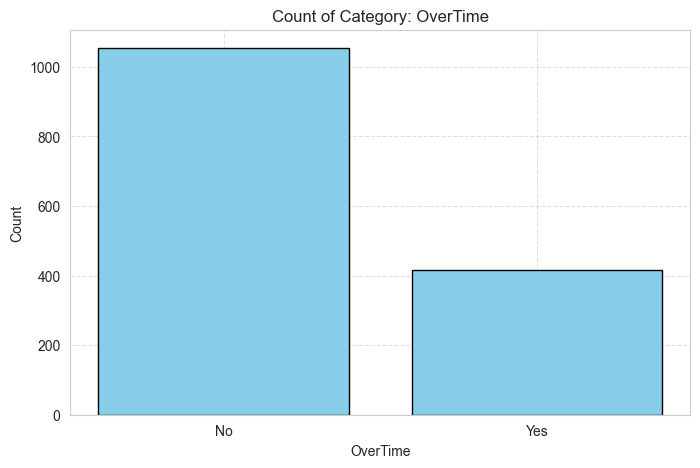

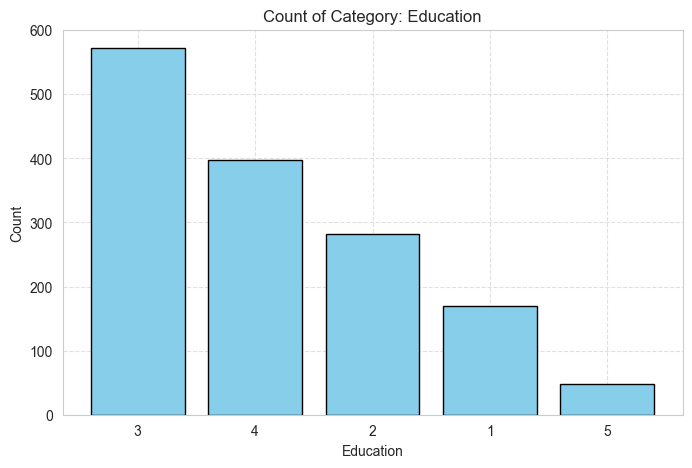

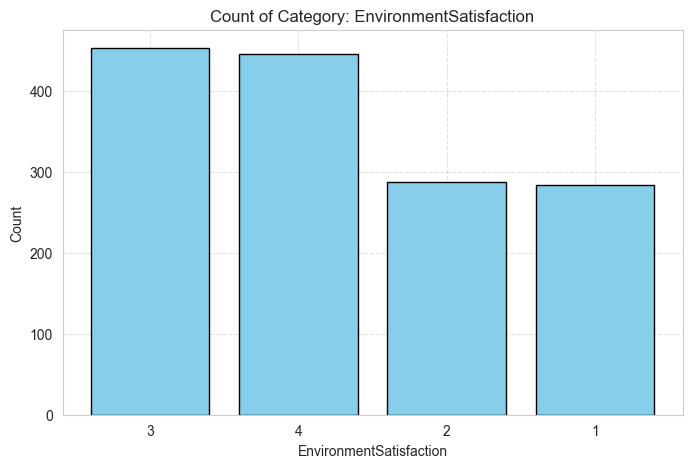

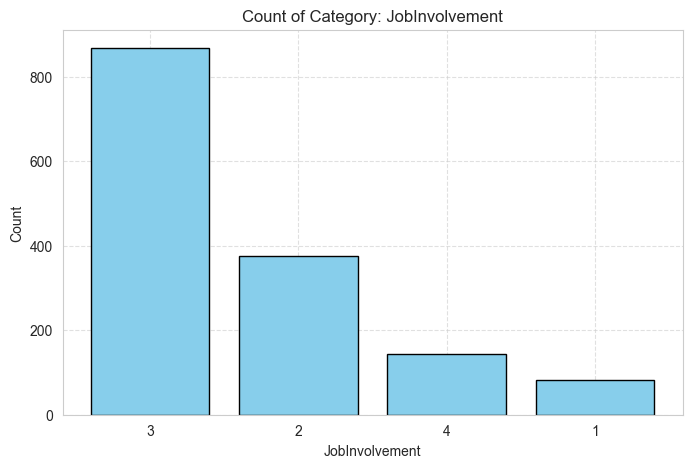

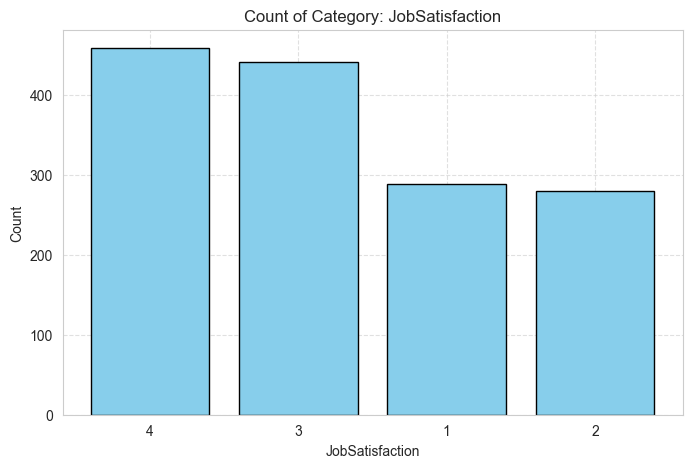

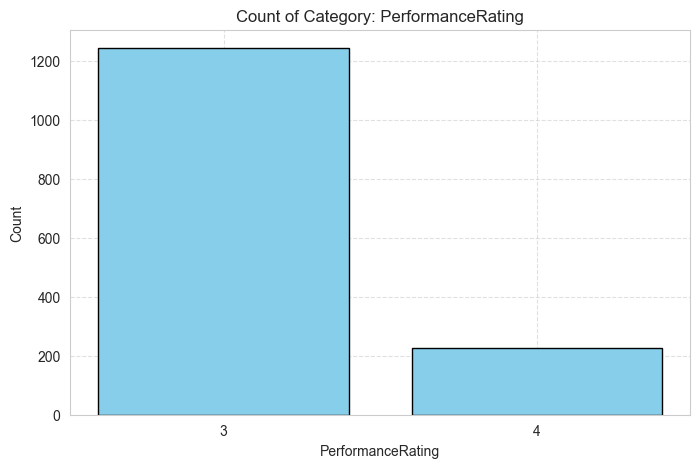

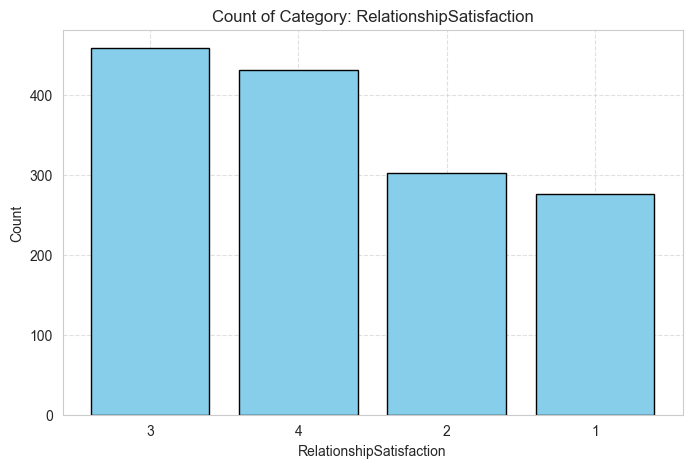

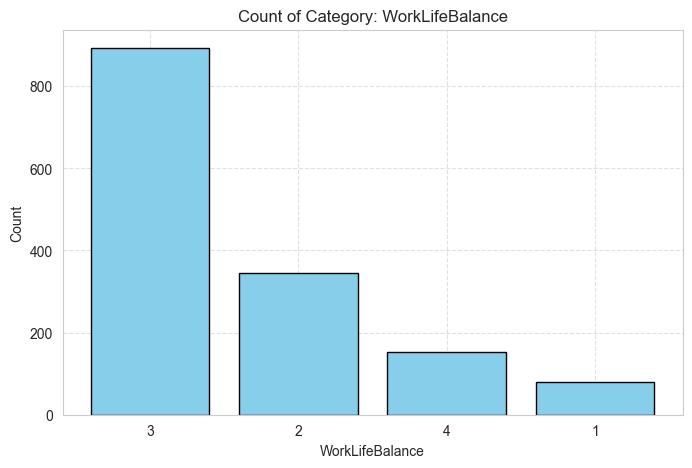

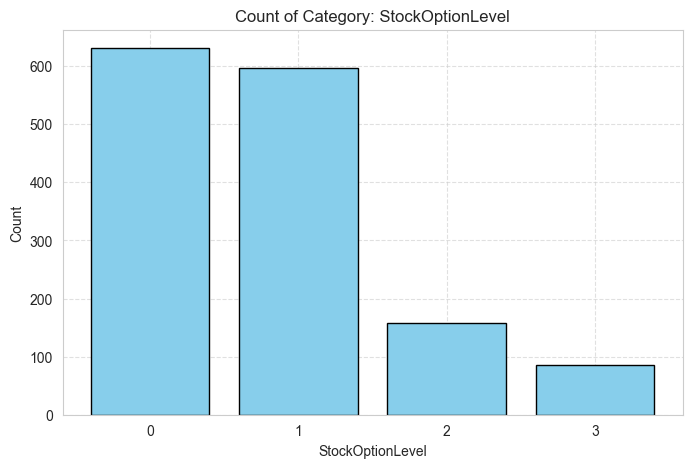

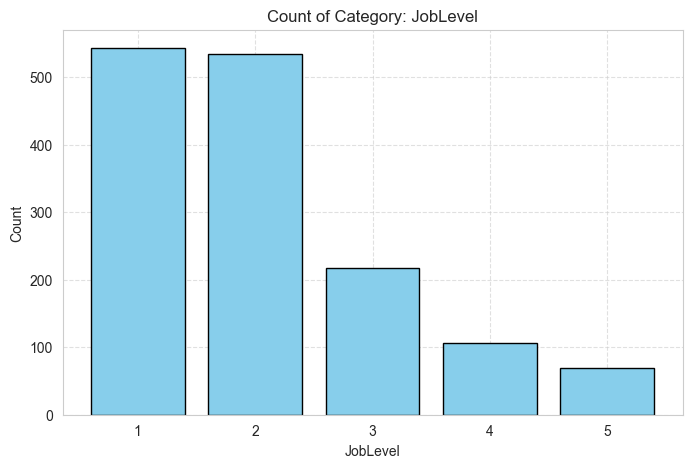

In [4]:
# same procedure for the categorical columns:
categorical_columns = [
                'Attrition',
                'BusinessTravel',
                'Department',
                'EducationField',
                'Gender',
                'JobRole',
                'MaritalStatus',
                'OverTime',
                'Education',
                'EnvironmentSatisfaction',
                'JobInvolvement',
                'JobSatisfaction',
                'PerformanceRating',
                'RelationshipSatisfaction',
                'WorkLifeBalance',
                'StockOptionLevel',
                'JobLevel'
]
#looping per categorical column
for category in categorical_columns:
    ibm_ds[category] = ibm_ds[category].astype(str)
    counts = ibm_ds[category].value_counts()
    plt.figure(figsize=(8,5))
    plt.bar(counts.index,counts.values, color = 'skyblue', edgecolor="black")
    plt.title("Distribution of Category: "+category+" within the dataset")
    plt.title("Count of Category: " + category)
    plt.xlabel(category)
    #better visuals for more than 3 categories, with large contents
    for value in counts.index:
        if len(counts.index) > 3 & len(value)>=3:
            #rotation based on the above criteria for visibility
            plt.xticks(rotation=65)
    plt.ylabel("Count")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

In [5]:
#removal of redundant columns
ibm_ds.drop(['EmployeeCount', # always 1
             'EmployeeNumber', #ID
             'Over18', # always 'Yes'
             'StandardHours' #always'80'
             ], axis="columns", inplace=True)

In [6]:
#turning to numeric some string values that should be numeric based on their contents
turn_to_numeric_list = ['EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance'
]
ibm_ds[turn_to_numeric_list] = np.float64(ibm_ds[turn_to_numeric_list])


-13493.0
24783.0
Lower quantile: 2911.0
Upper quantile: 8379.0


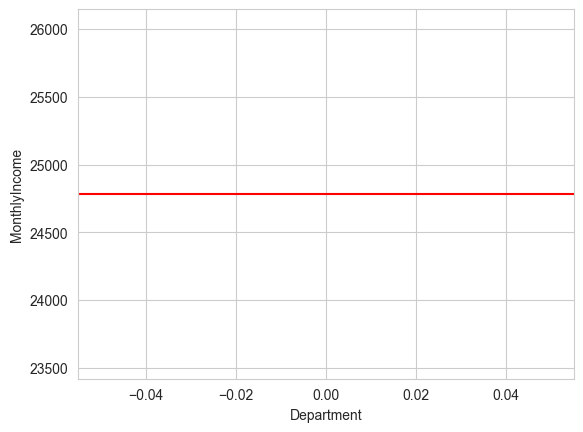

-13493.0
24783.0
Lower quantile: 2911.0
Upper quantile: 8379.0


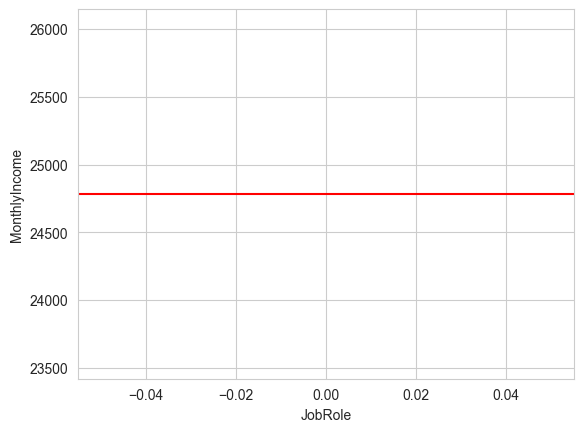

-13493.0
24783.0
Lower quantile: 2911.0
Upper quantile: 8379.0


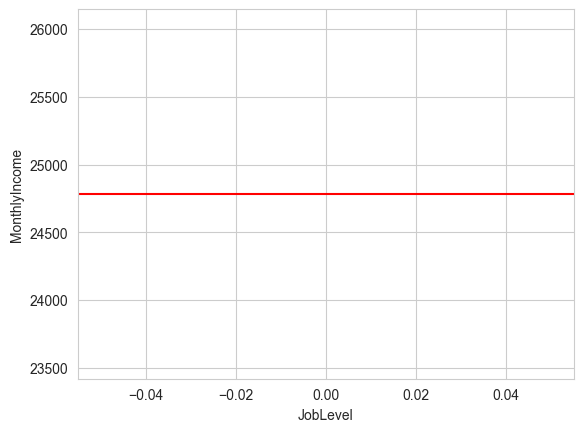

-21.0
42.0
Lower quantile: 6.0
Upper quantile: 15.0


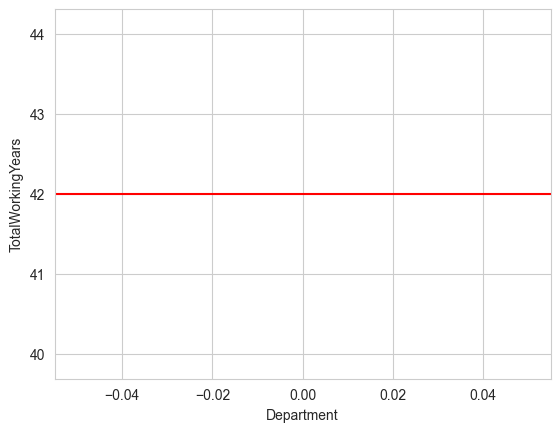

-21.0
42.0
Lower quantile: 6.0
Upper quantile: 15.0


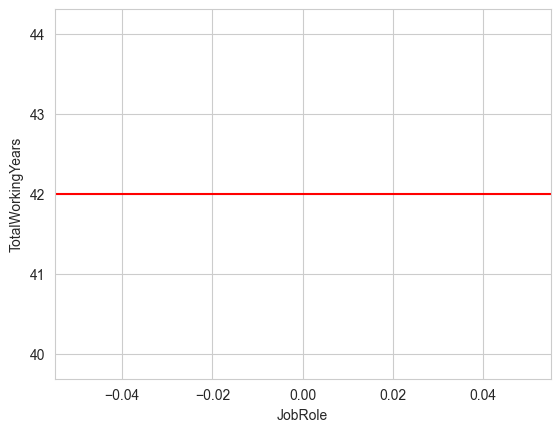

-21.0
42.0
Lower quantile: 6.0
Upper quantile: 15.0


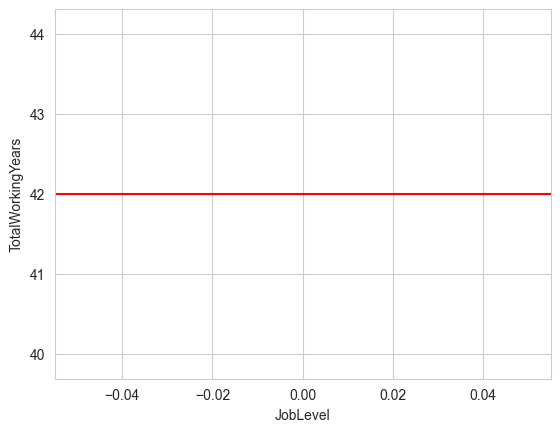

-34.0
50.0
Lower quantile: 2.0
Upper quantile: 14.0


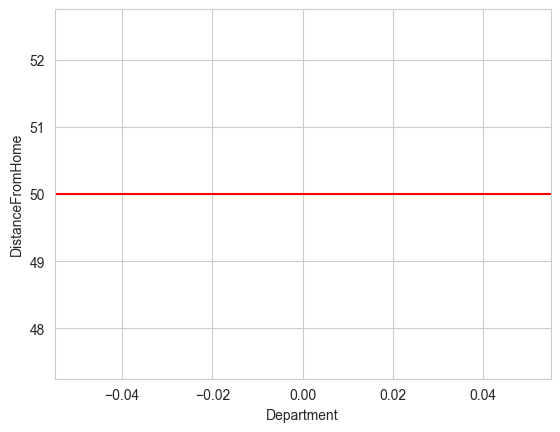

-34.0
50.0
Lower quantile: 2.0
Upper quantile: 14.0


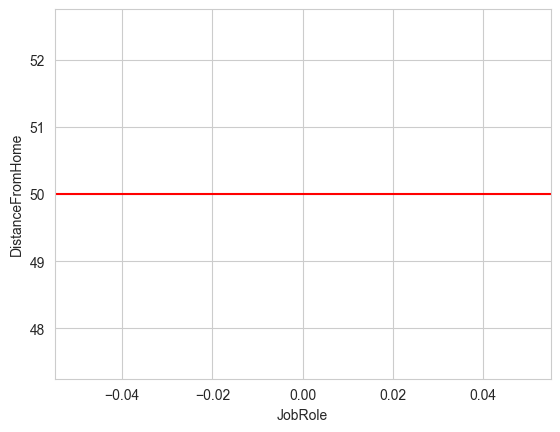

-34.0
50.0
Lower quantile: 2.0
Upper quantile: 14.0


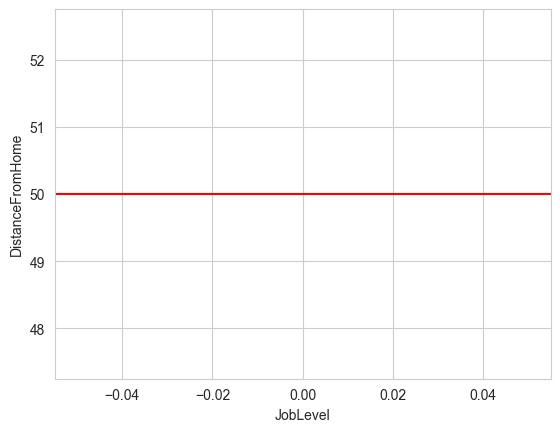

-8.0
13.0
Lower quantile: 1.0
Upper quantile: 4.0


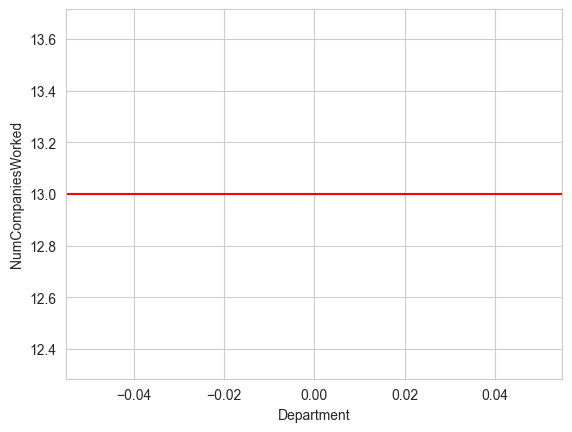

-8.0
13.0
Lower quantile: 1.0
Upper quantile: 4.0


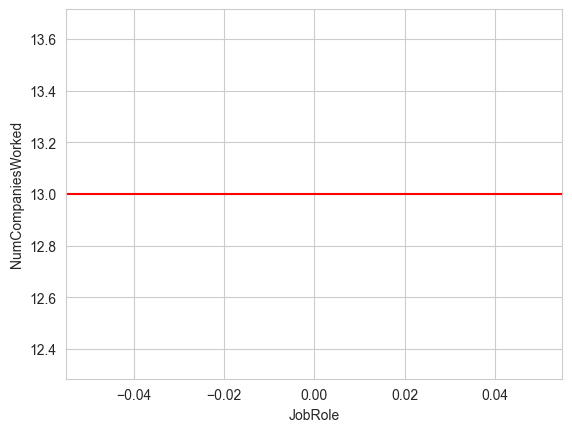

-8.0
13.0
Lower quantile: 1.0
Upper quantile: 4.0


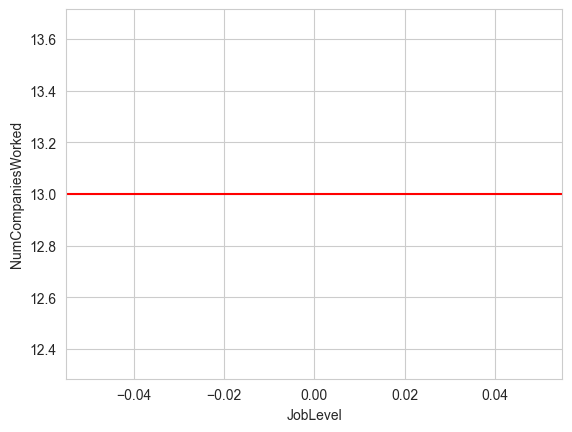

-15.0
27.0
Lower quantile: 3.0
Upper quantile: 9.0


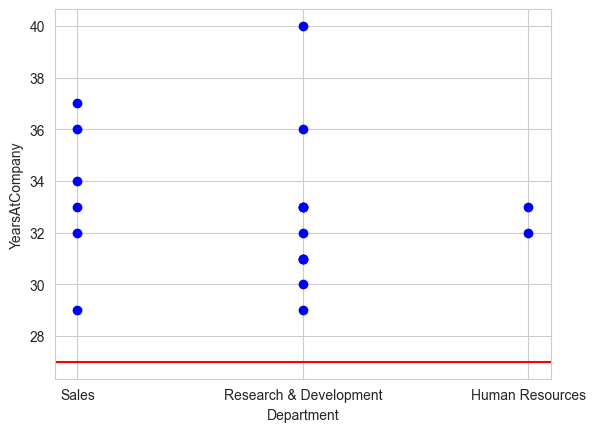

-15.0
27.0
Lower quantile: 3.0
Upper quantile: 9.0


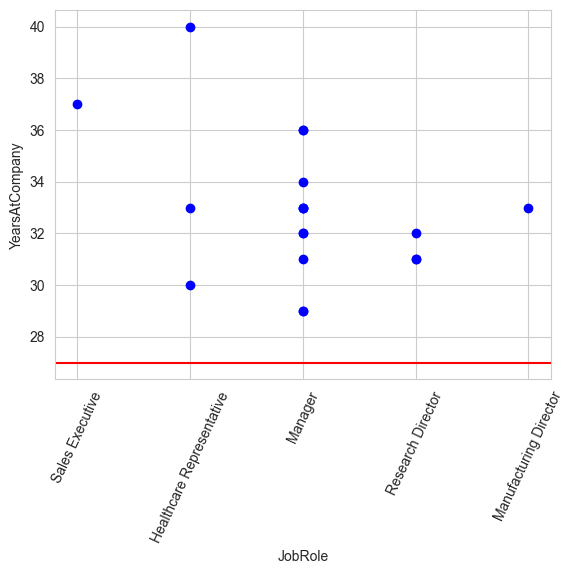

-15.0
27.0
Lower quantile: 3.0
Upper quantile: 9.0


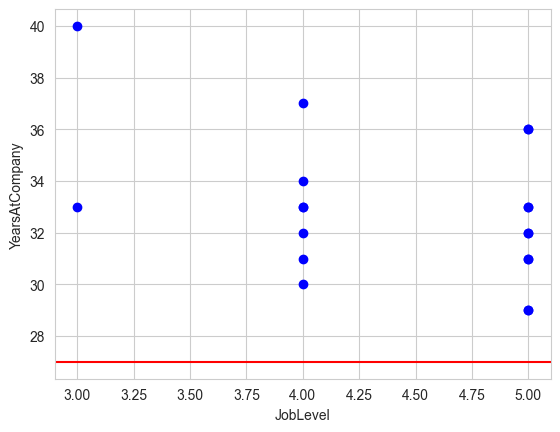

-13.0
22.0
Lower quantile: 2.0
Upper quantile: 7.0


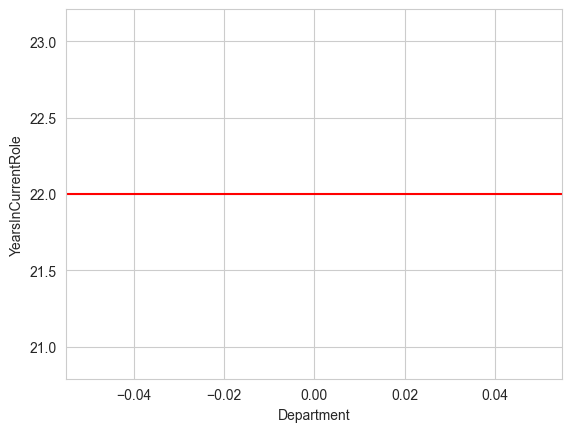

-13.0
22.0
Lower quantile: 2.0
Upper quantile: 7.0


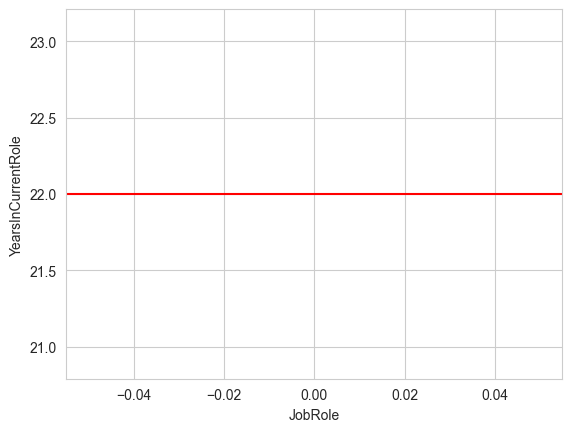

-13.0
22.0
Lower quantile: 2.0
Upper quantile: 7.0


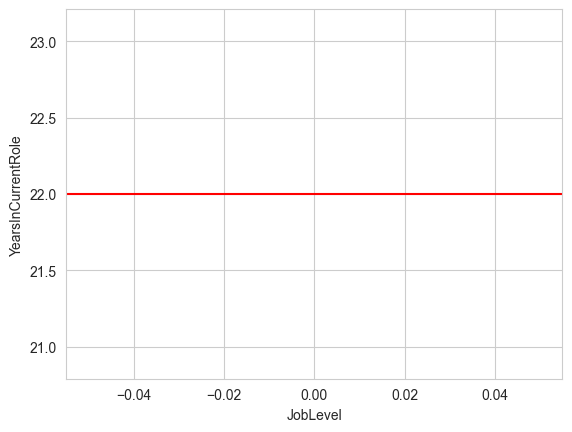

-9.0
12.0
Lower quantile: 0.0
Upper quantile: 3.0


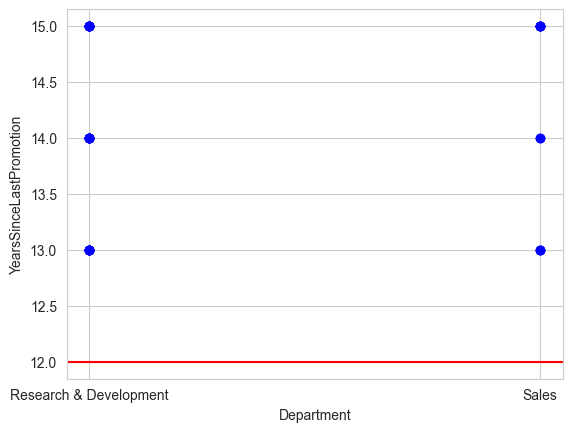

-9.0
12.0
Lower quantile: 0.0
Upper quantile: 3.0


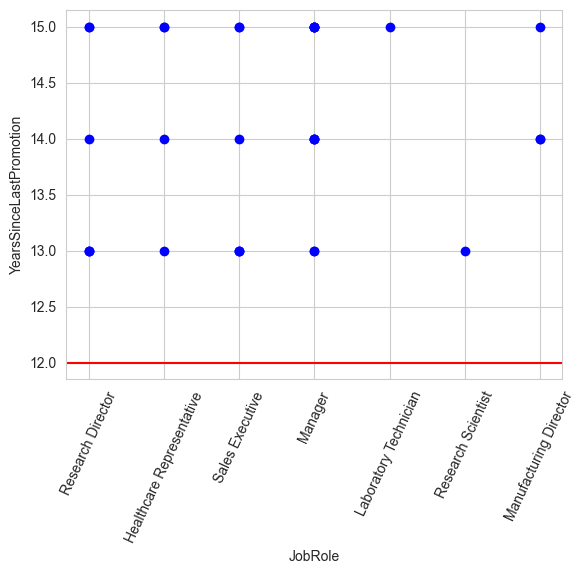

-9.0
12.0
Lower quantile: 0.0
Upper quantile: 3.0


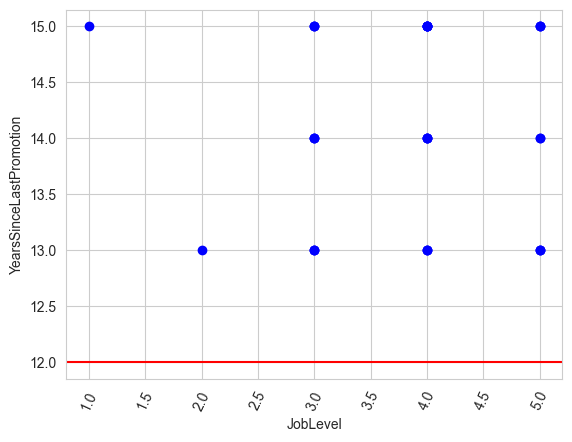

In [7]:
#search for outliers and extreme values

numericals_outlier_check = [
    'MonthlyIncome',
    'TotalWorkingYears',
    'DistanceFromHome',
    'NumCompaniesWorked',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion'
]

# Λίστα με τις κατηγορηματικές μεταβλητές πλαισίωσης (Categorical Context Features)
categoricals_outlier_check = [
    'Department',
    'JobRole',
    'JobLevel'
]

def find_outliers (ds, numerical_column_name, groupby_col):
    q1 = ds[numerical_column_name].quantile(0.25)
    q3 = ds[numerical_column_name].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 3 * IQR
    upper = q3 + 3 * IQR
    print(f"{lower}\n{upper}")
    outliers = ds[(ds[numerical_column_name] < lower) | (ds[numerical_column_name] > upper)]
    print (f"Lower quantile: {q1}\nUpper quantile: {q3}")
    #creating the scatterplot that shows each values, having a line on the upper limit.
    plt.scatter(outliers[groupby_col] ,outliers[numerical_column_name], color='blue', marker='o')
    plt.ylabel(numerical_column_name)
    plt.xlabel(groupby_col)
    if len(outliers[groupby_col].unique()) > 3: plt.xticks(rotation=65)
    # plt.title('Prices per square meter Outliers per city')
    plt.axhline(y=upper, color='r', linestyle='-', label='Upper Bound Extremes')
    plt.show()

for nc in numericals_outlier_check:
    for cc in categoricals_outlier_check:
        find_outliers(ibm_ds, nc, cc)


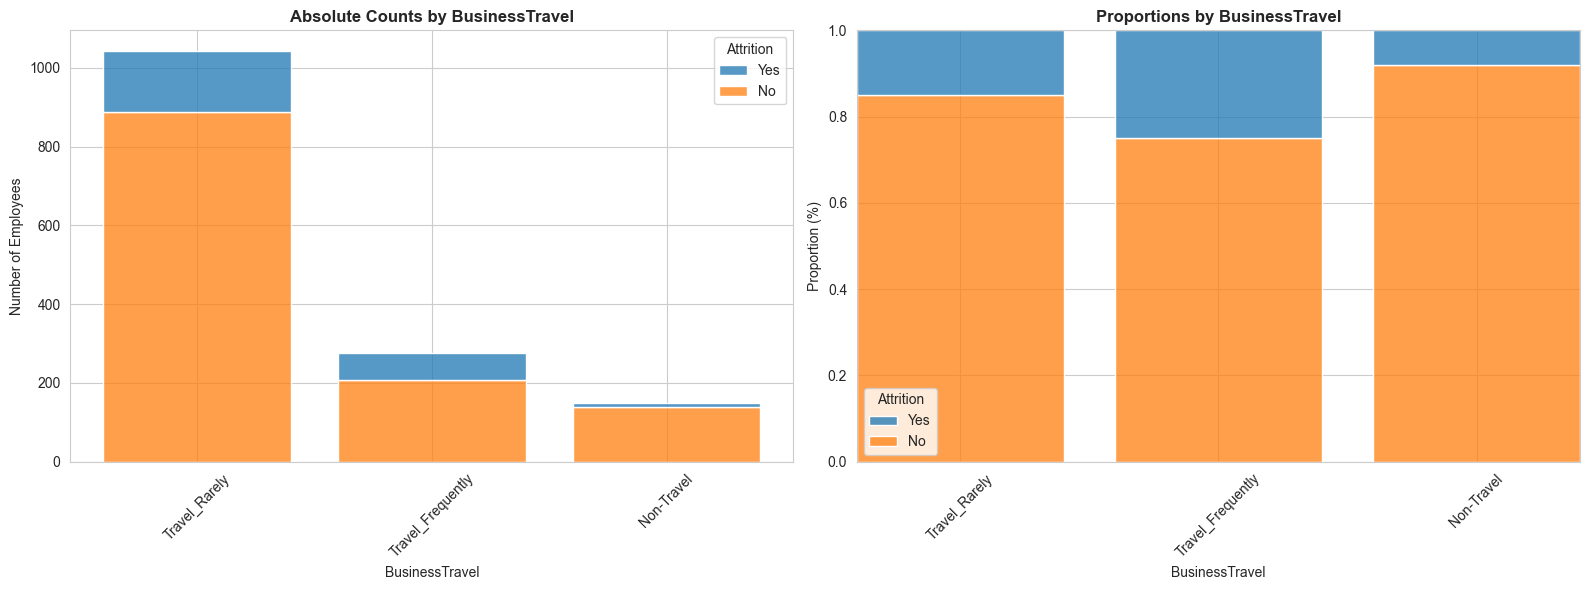

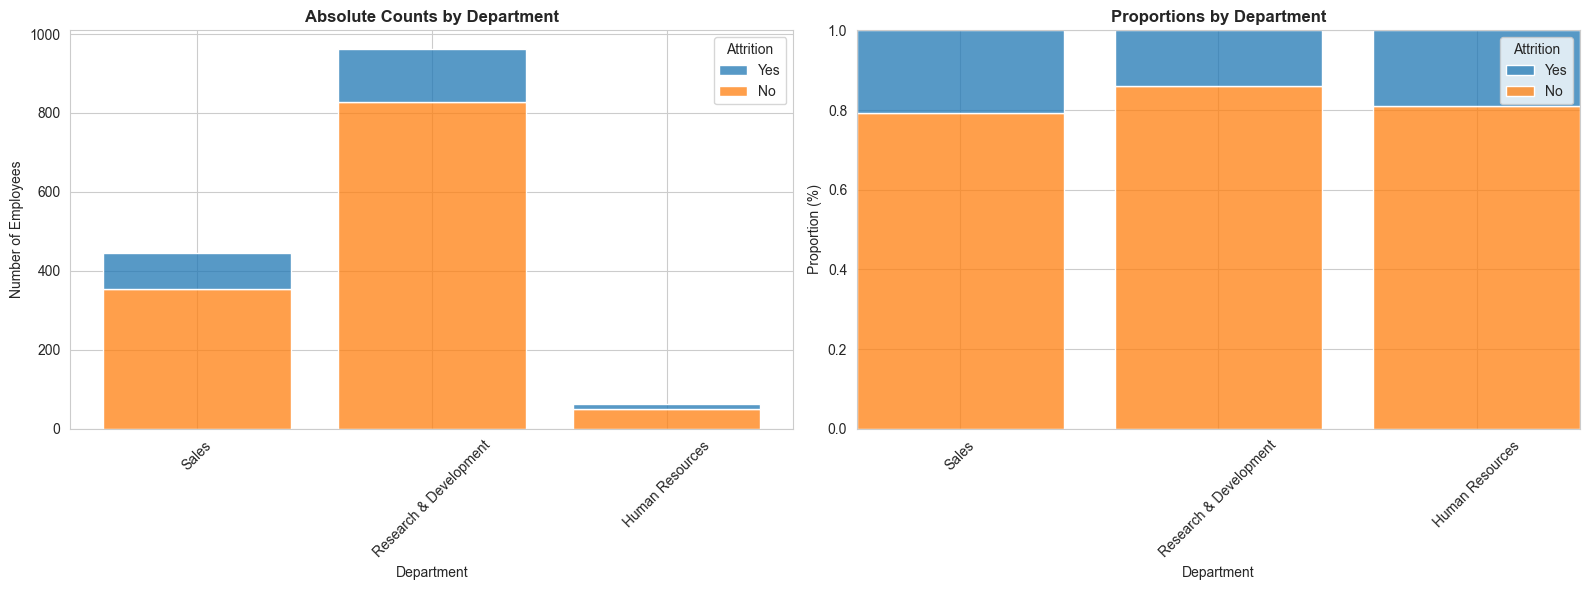

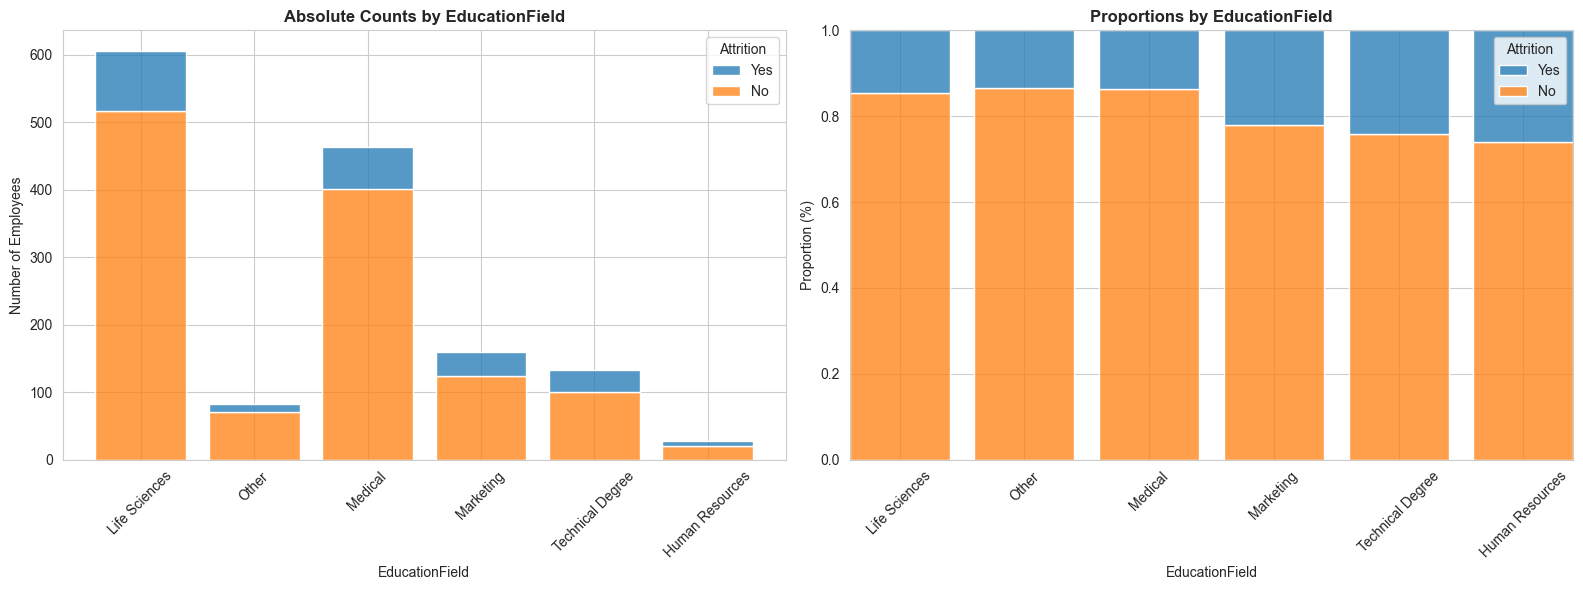

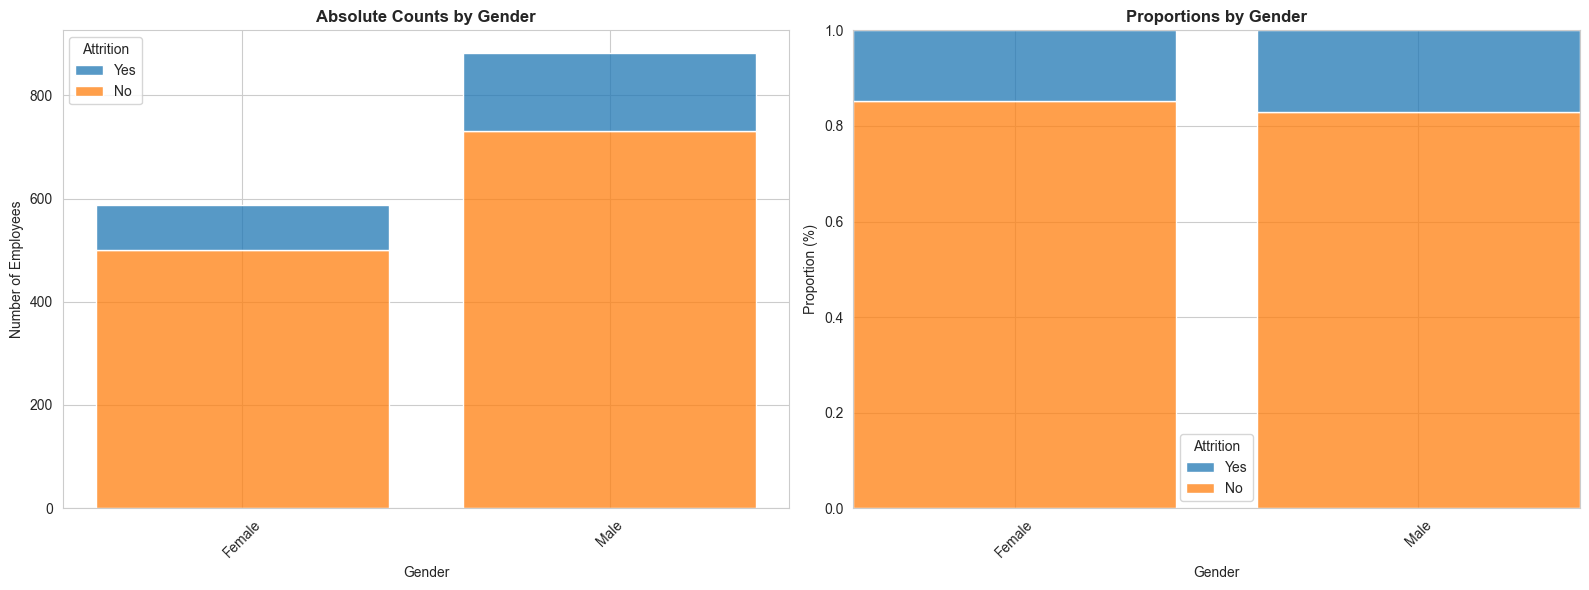

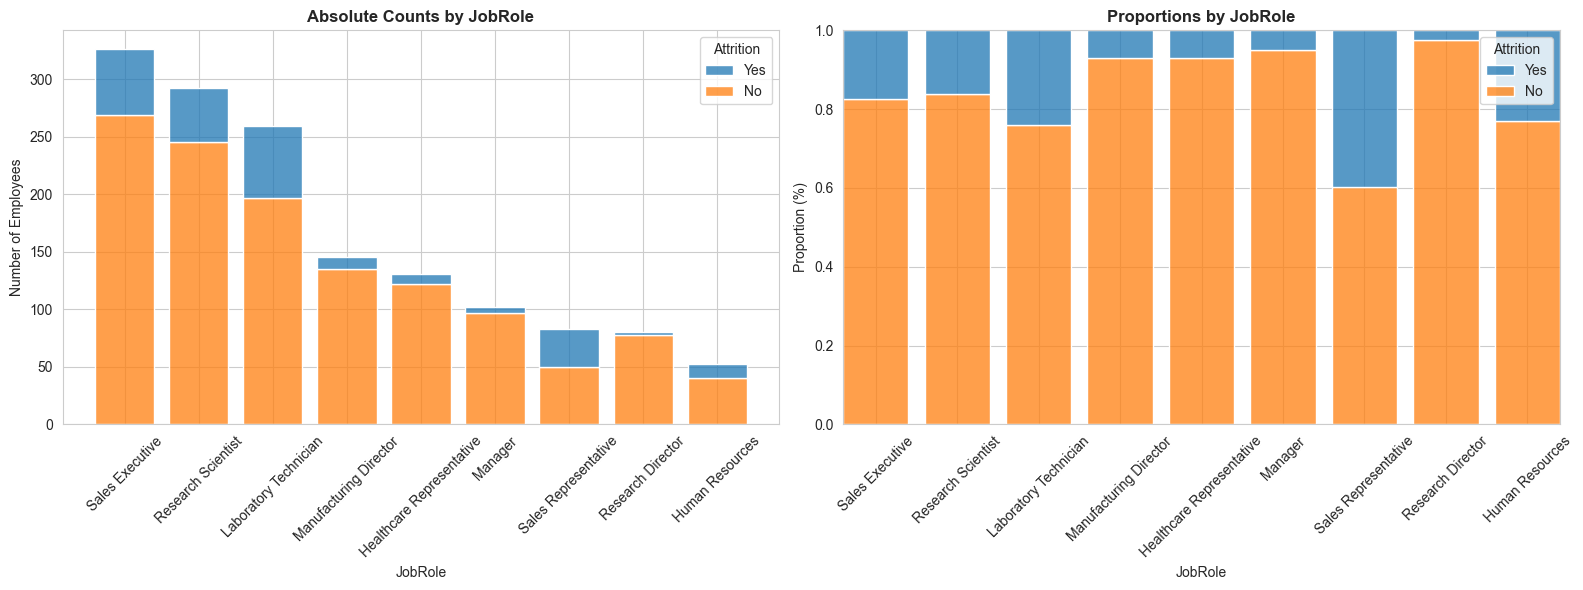

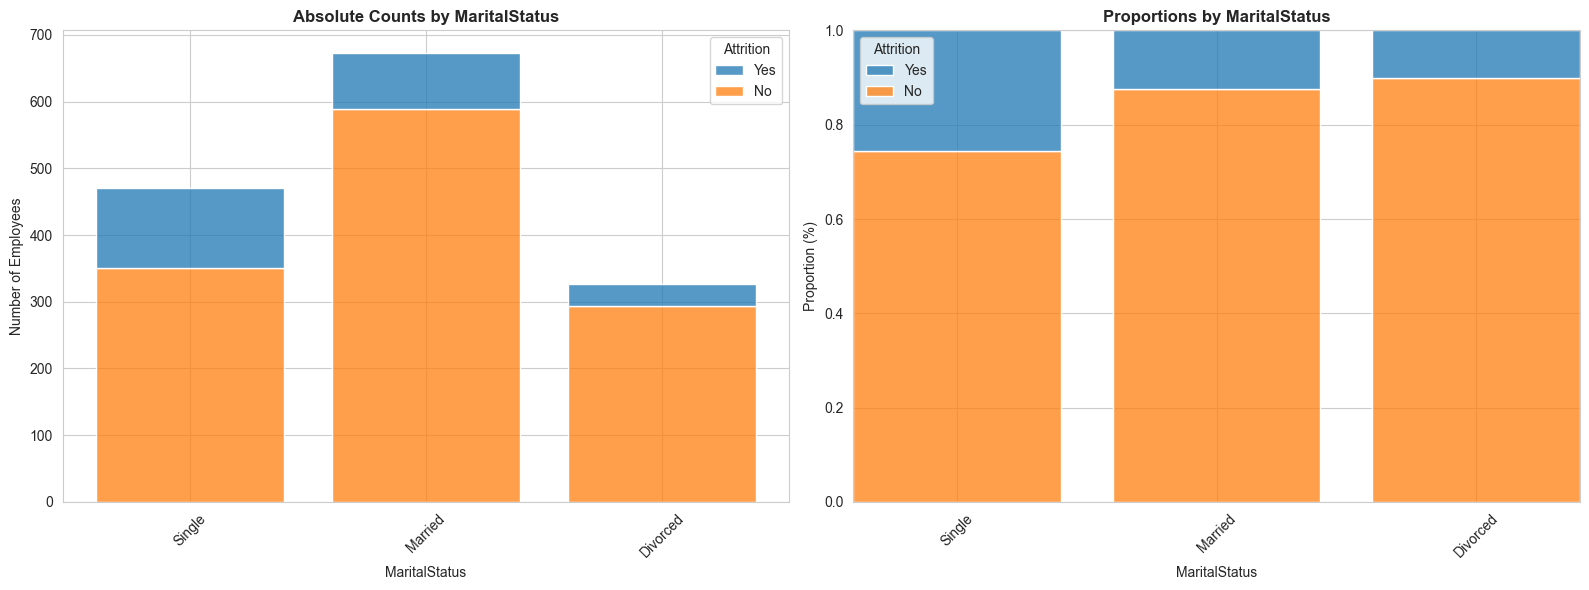

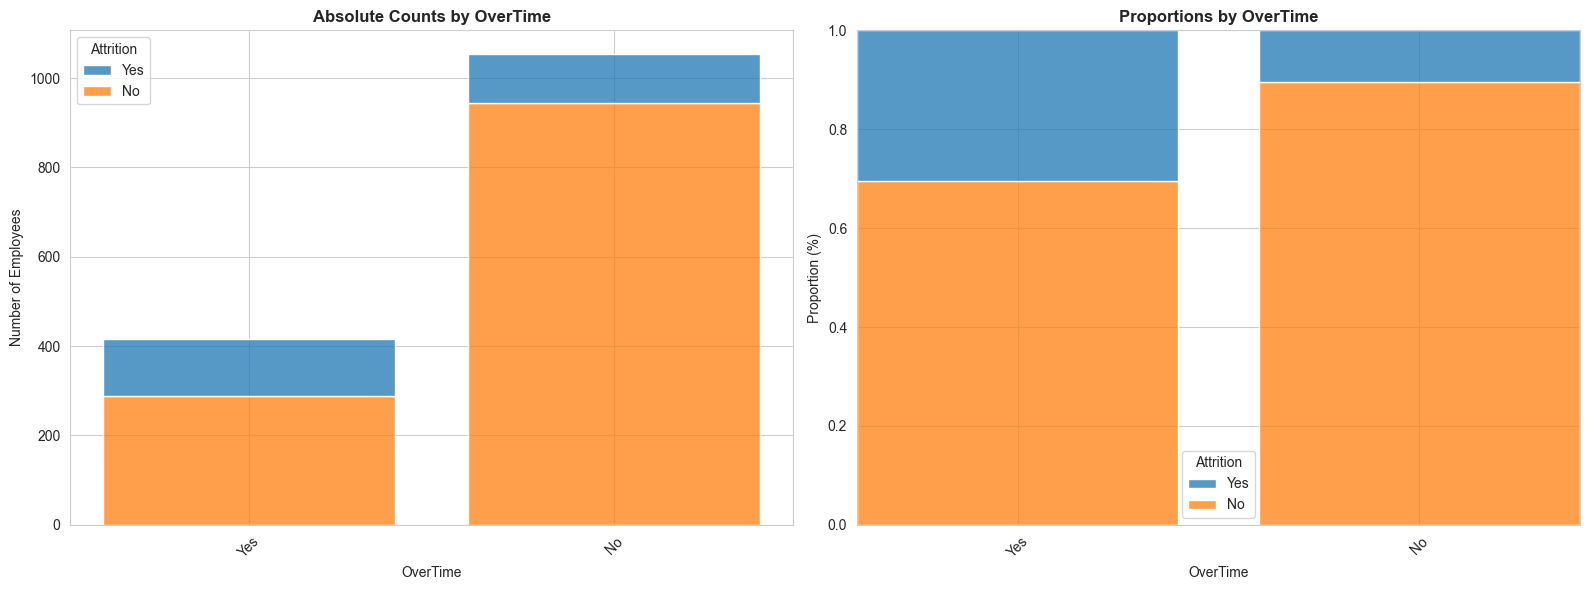

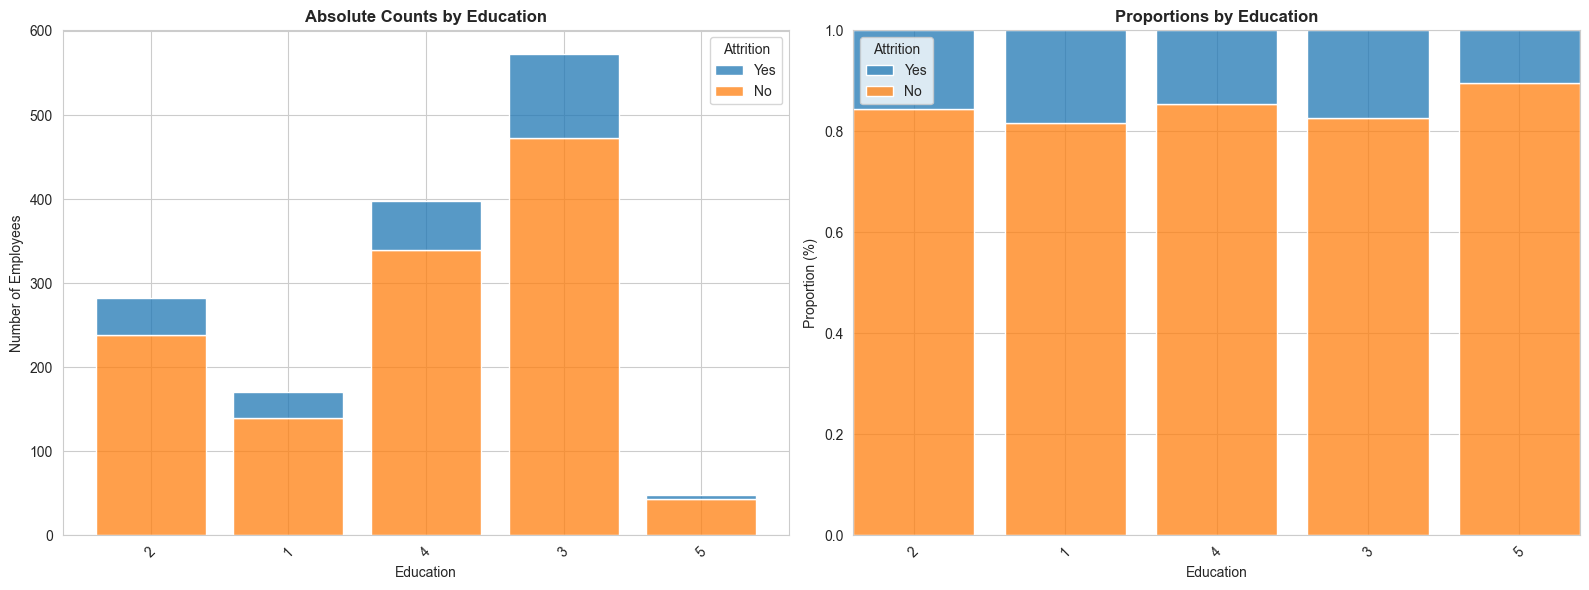

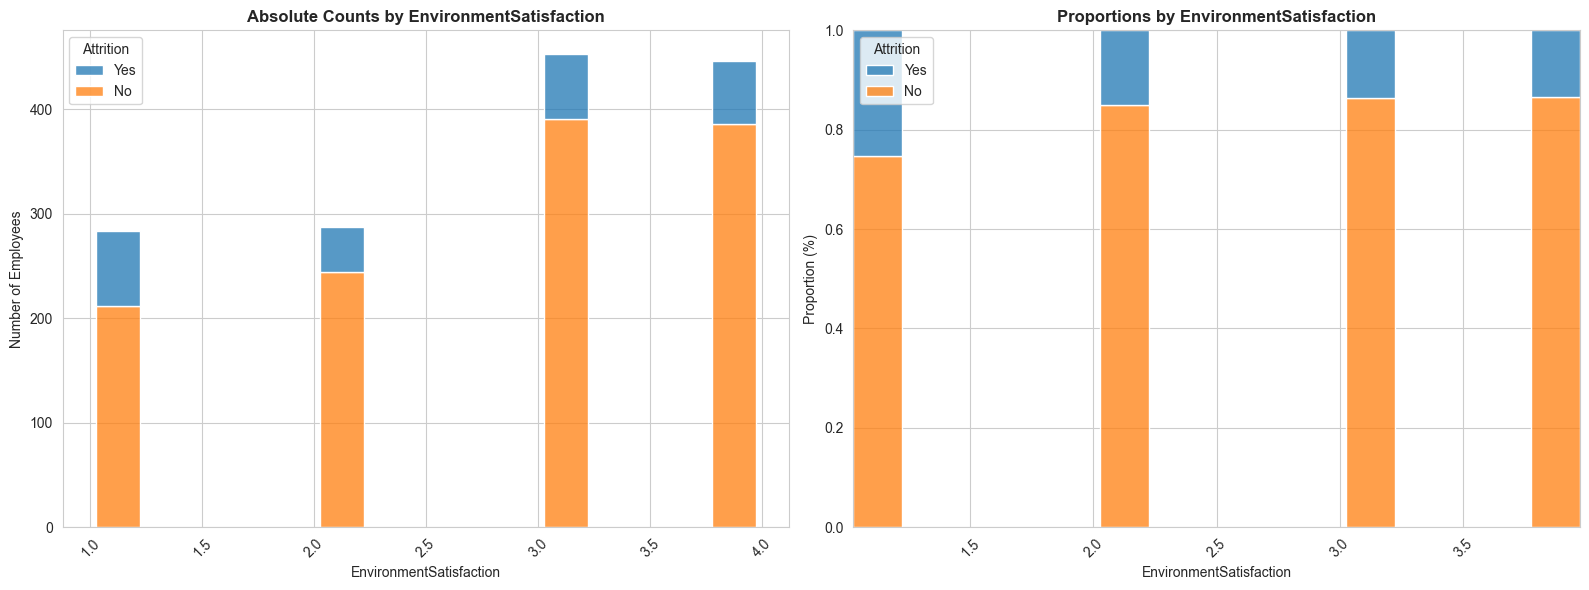

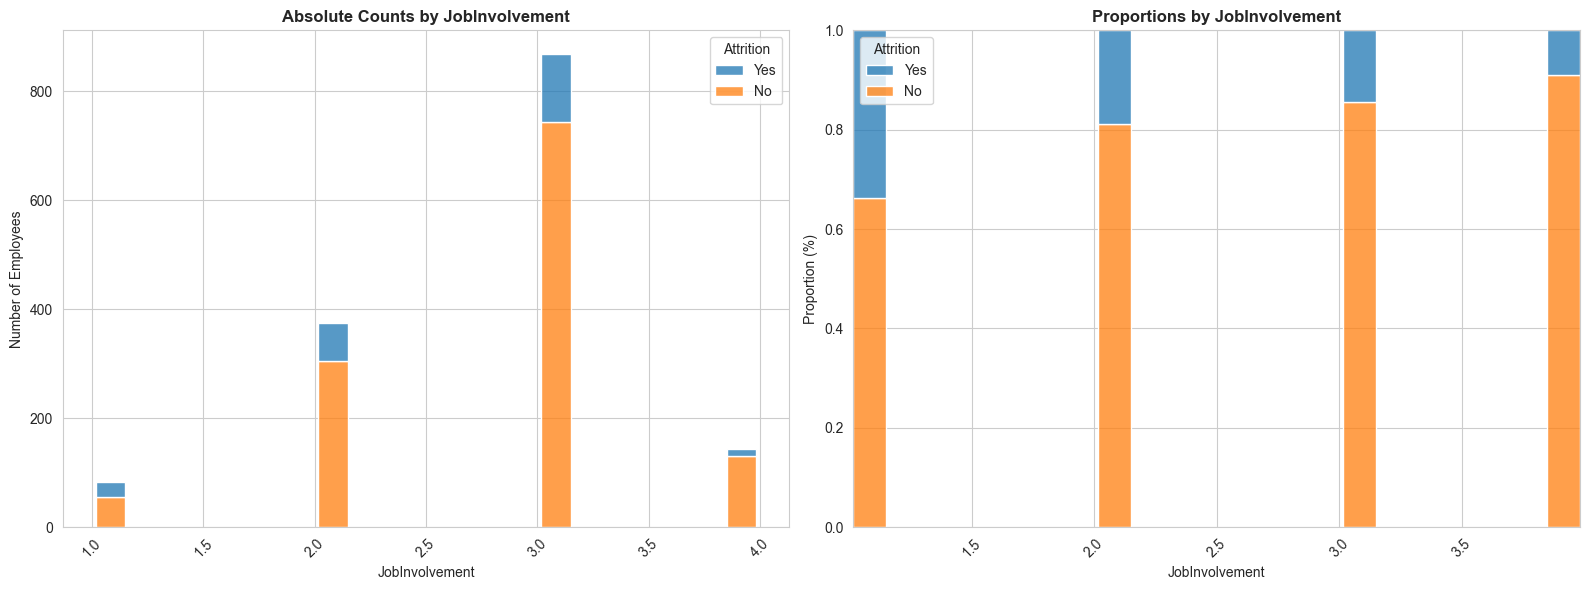

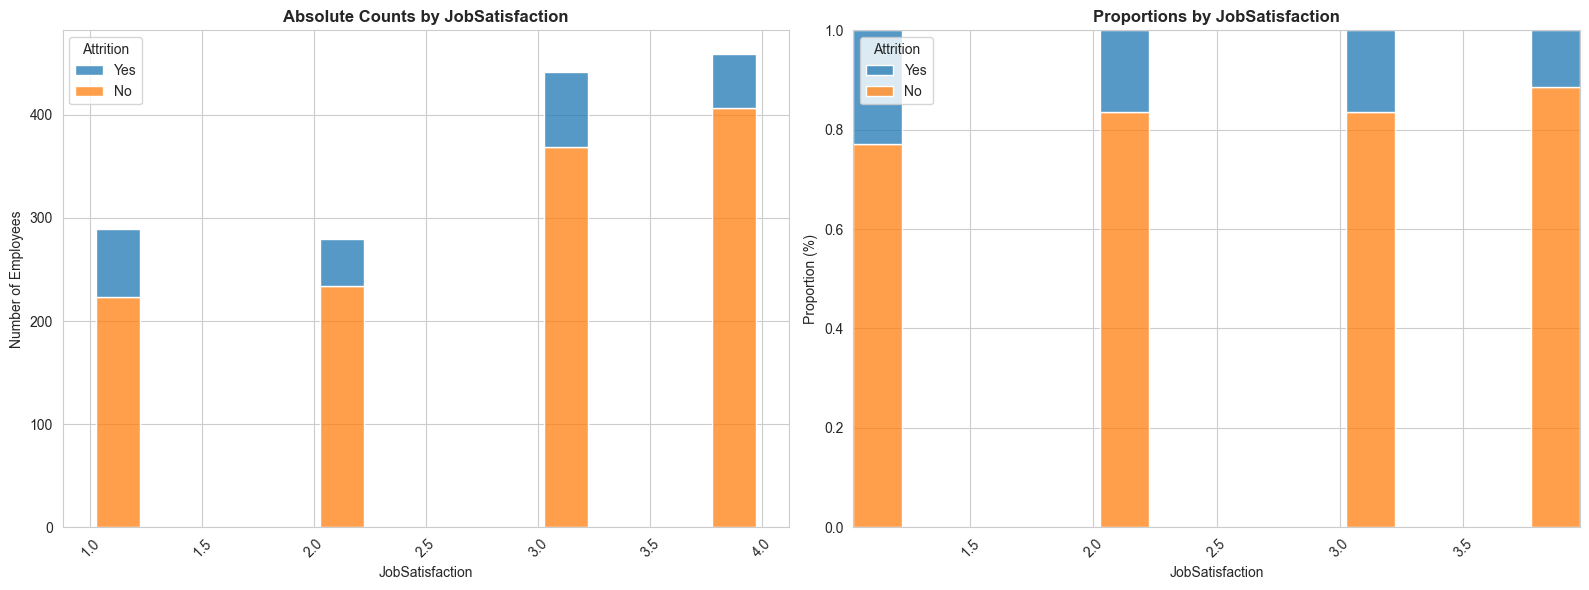

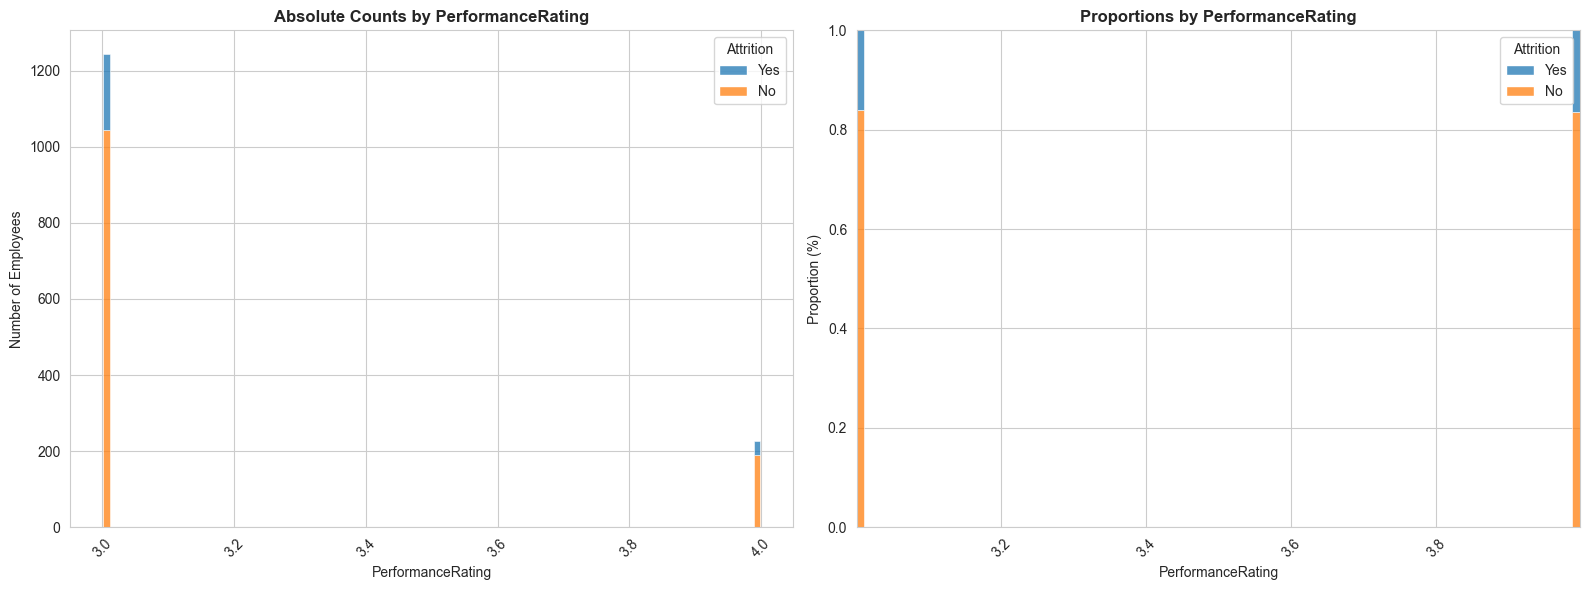

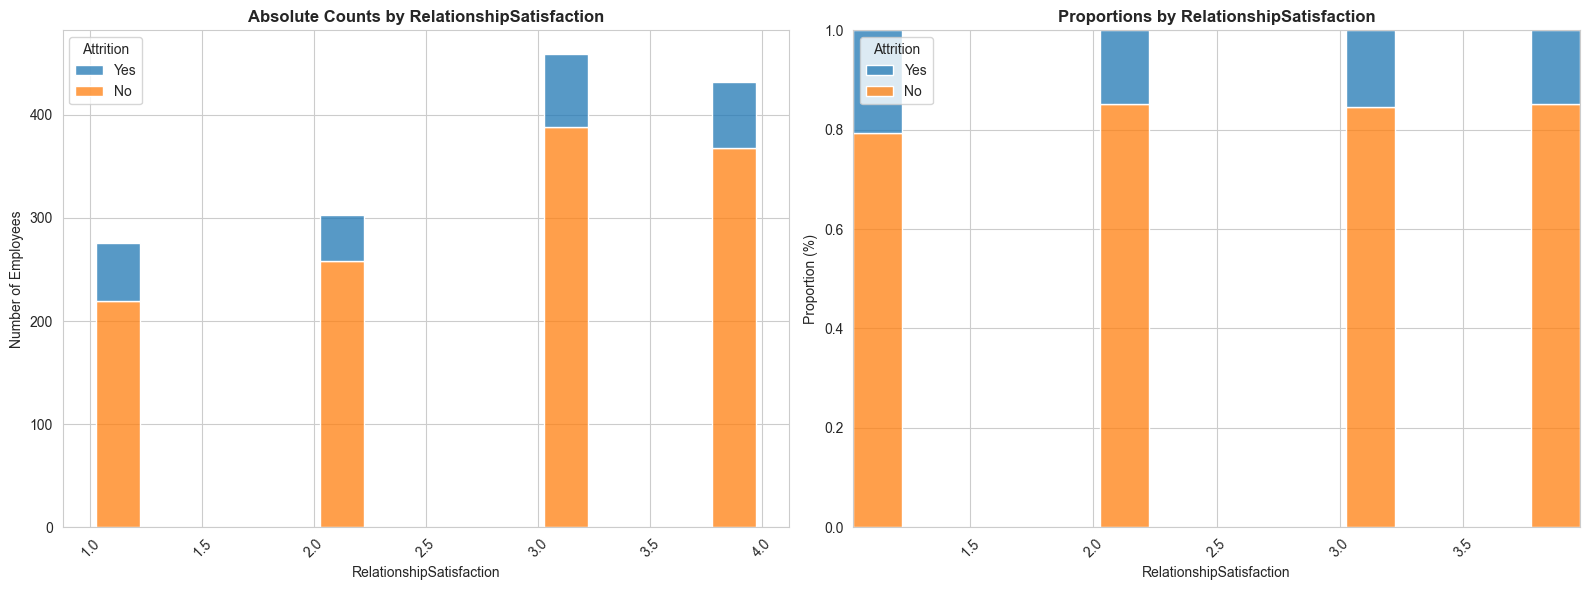

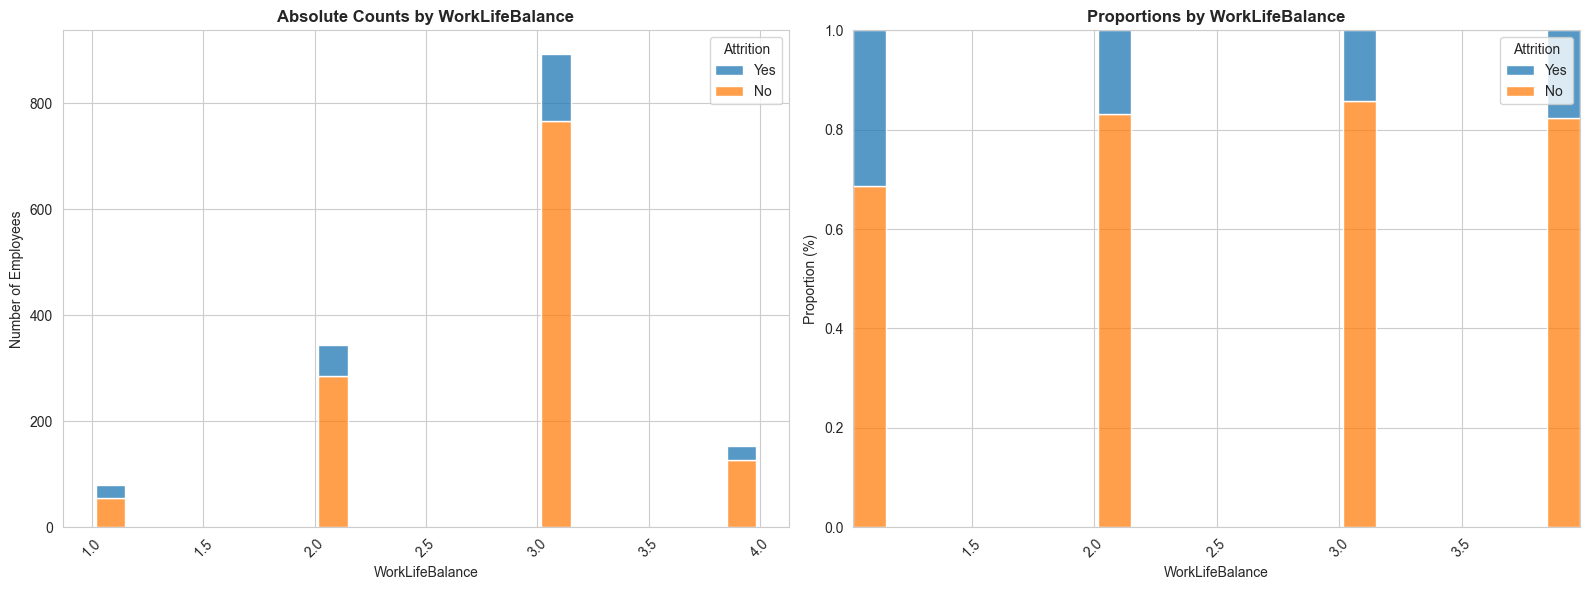

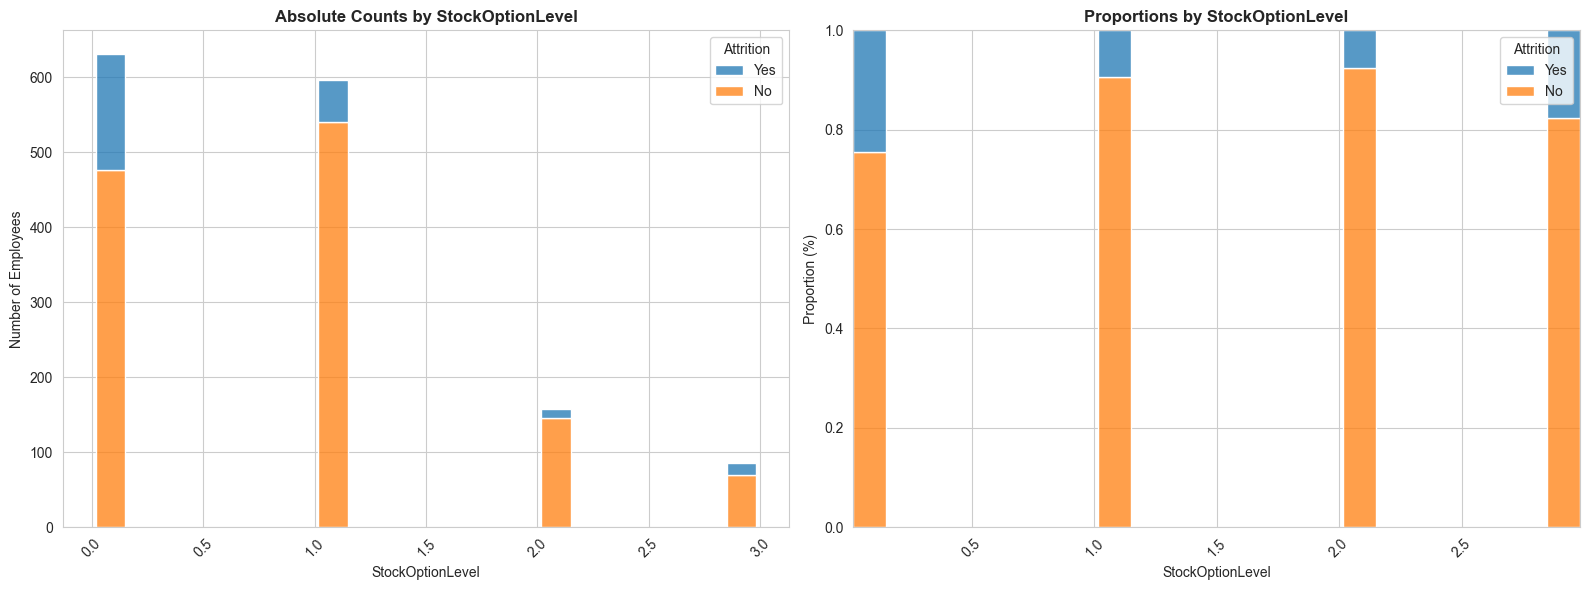

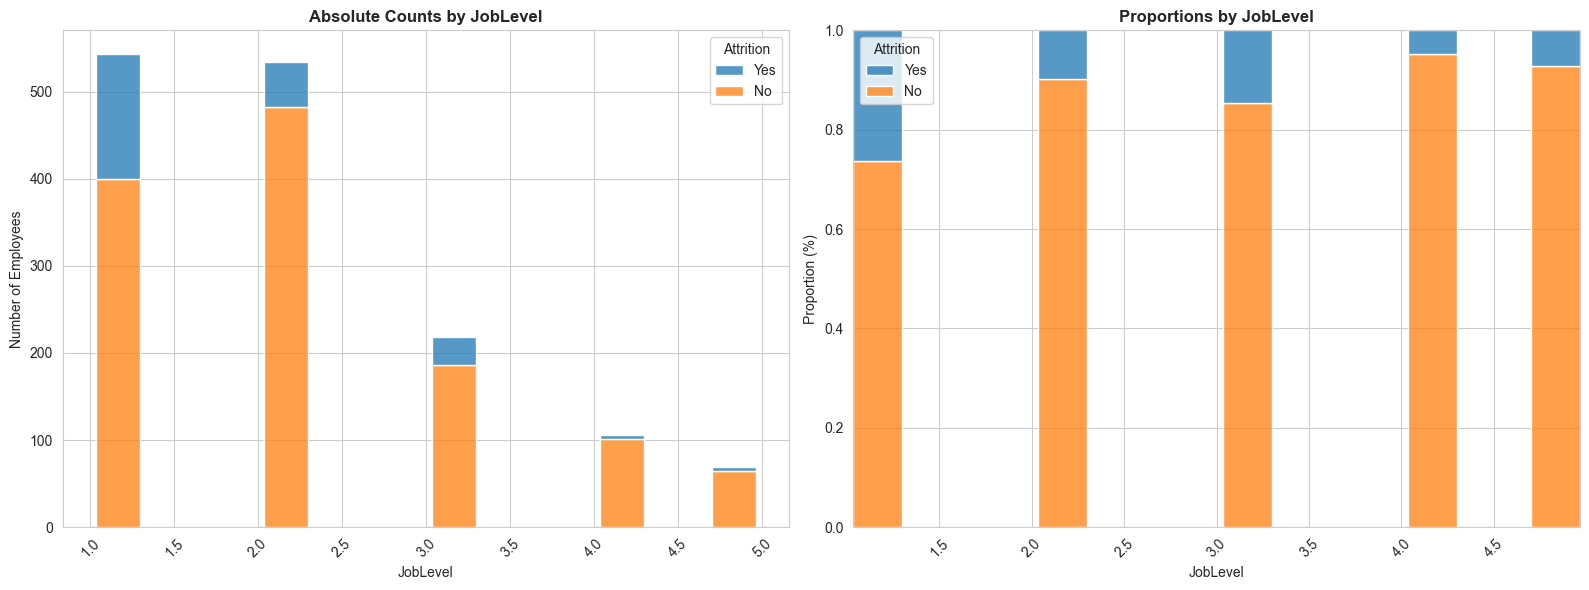

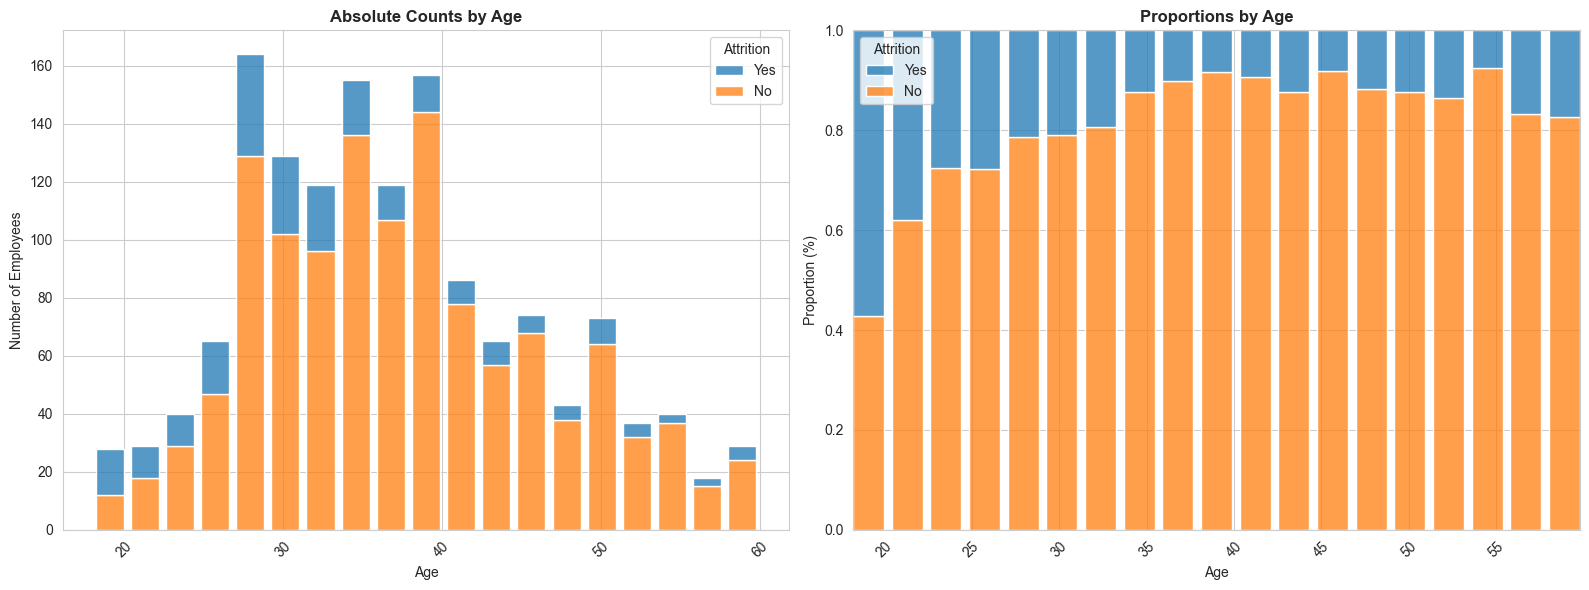

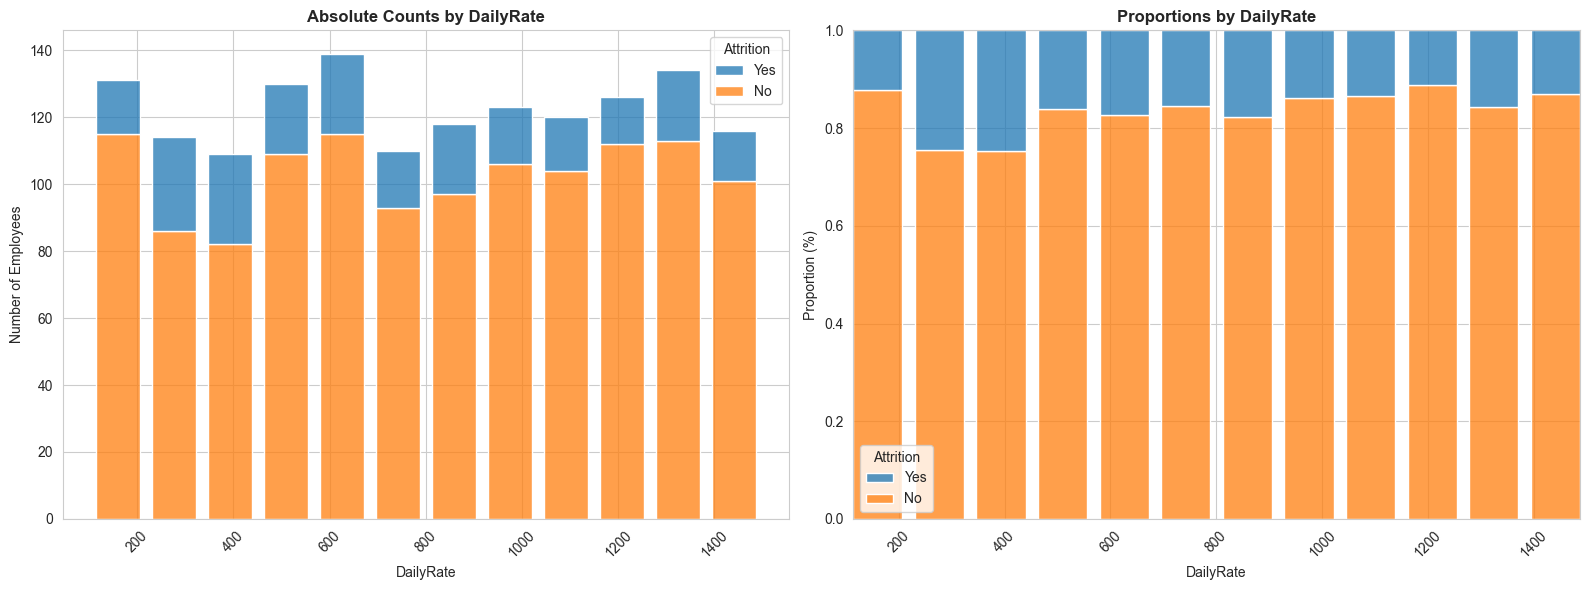

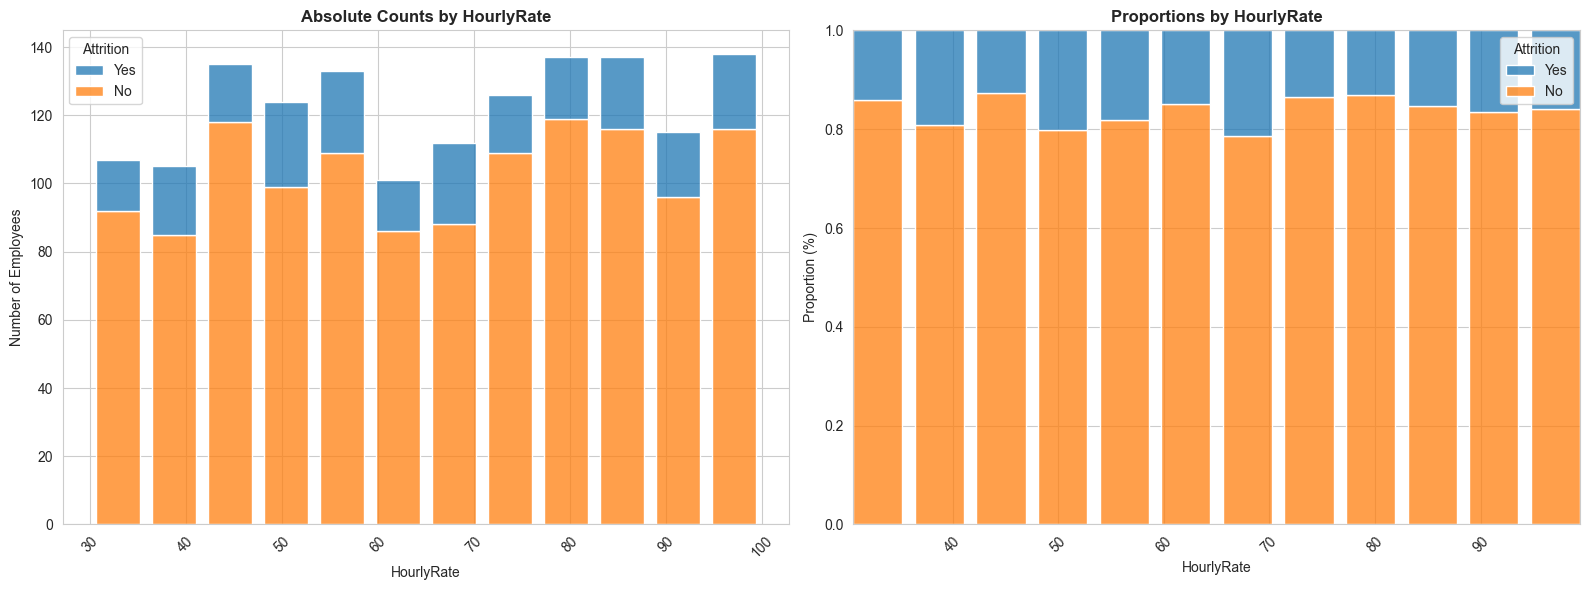

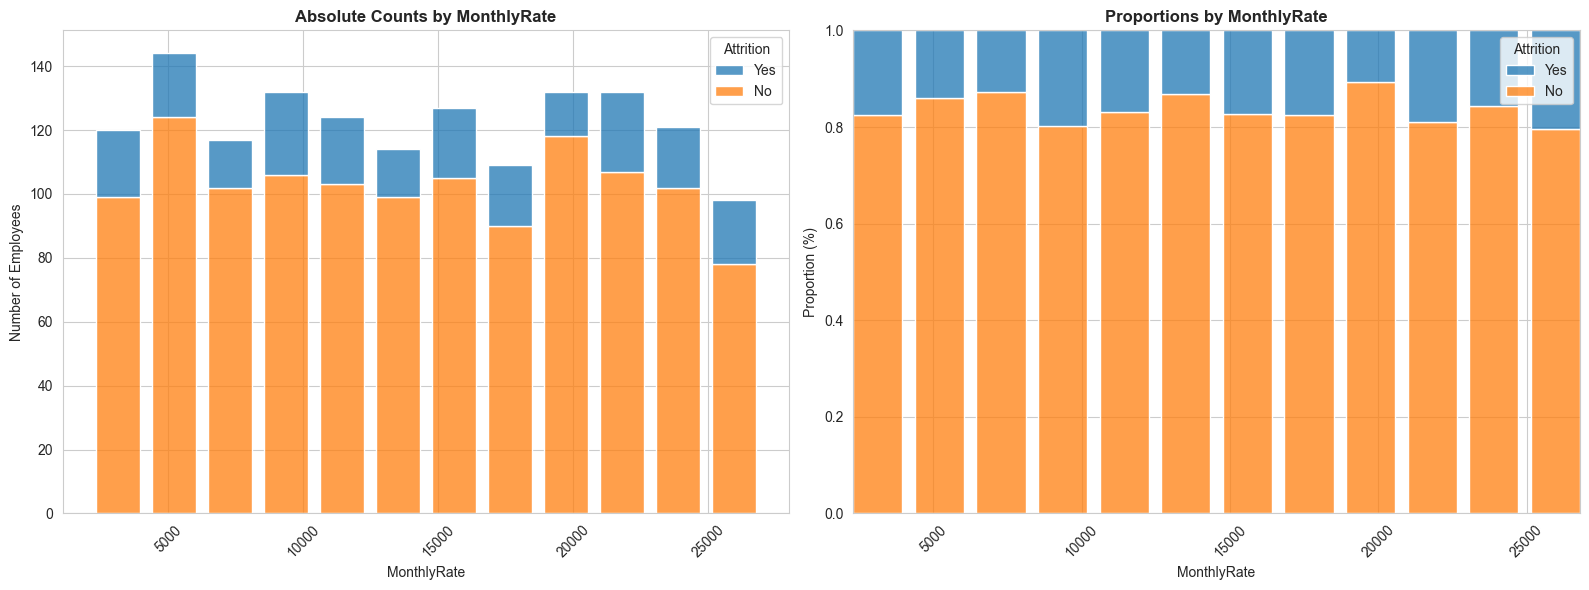

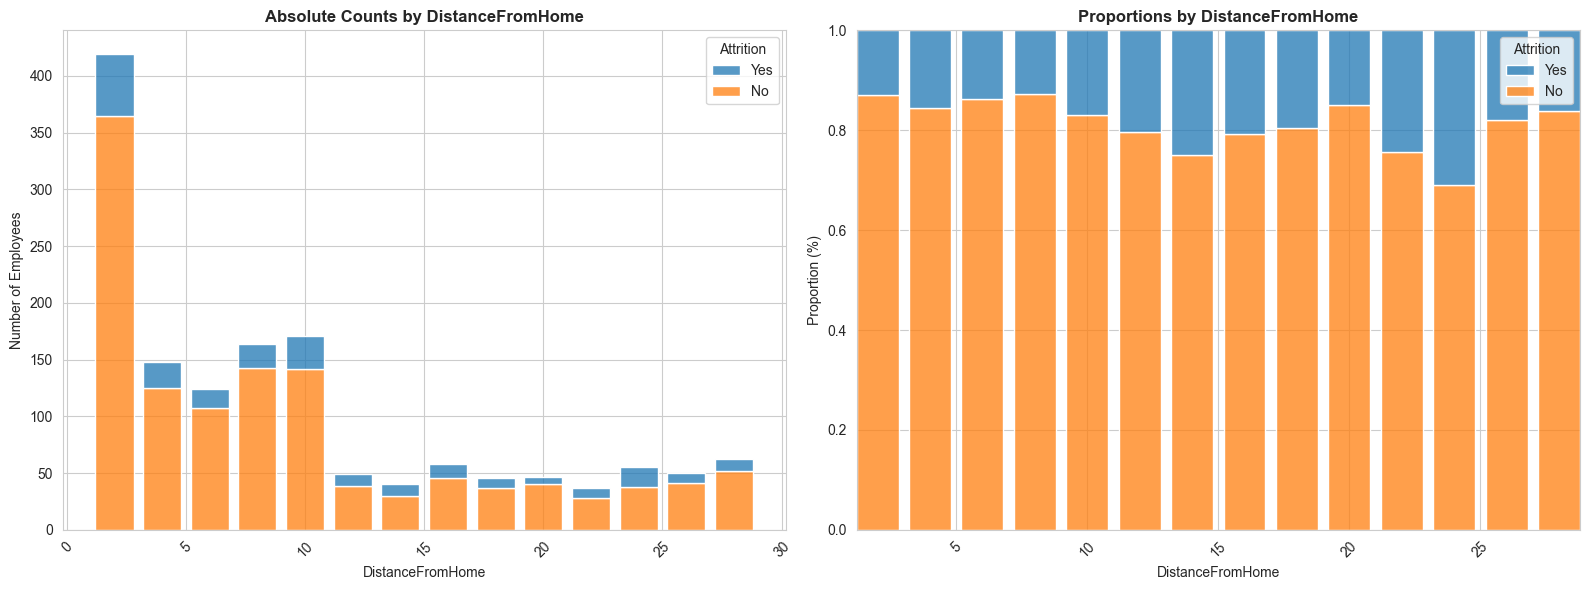

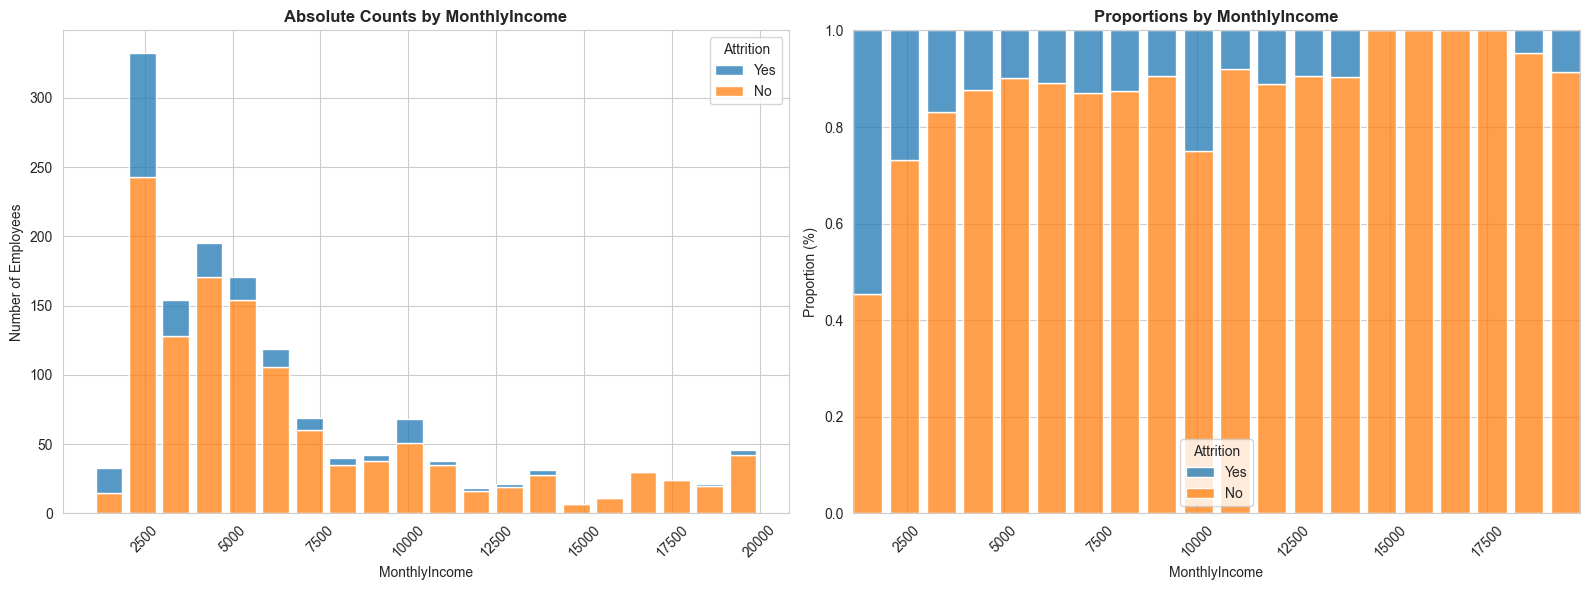

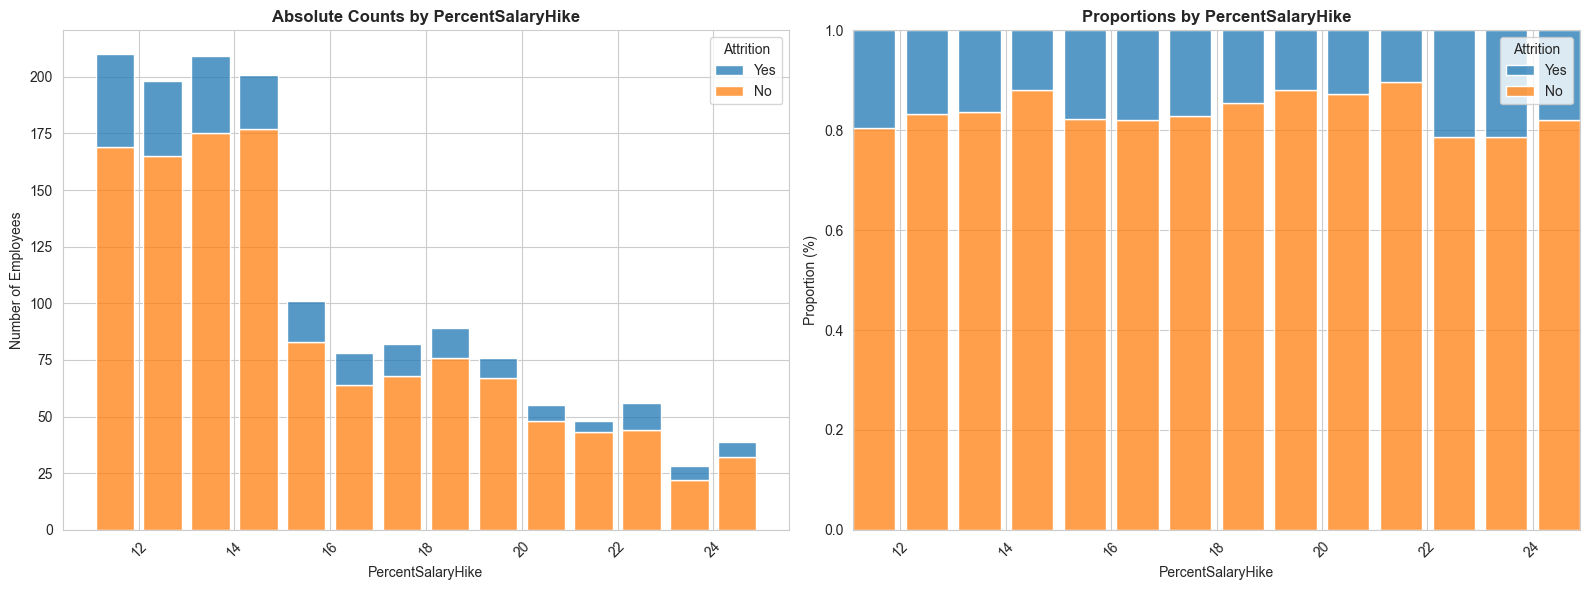

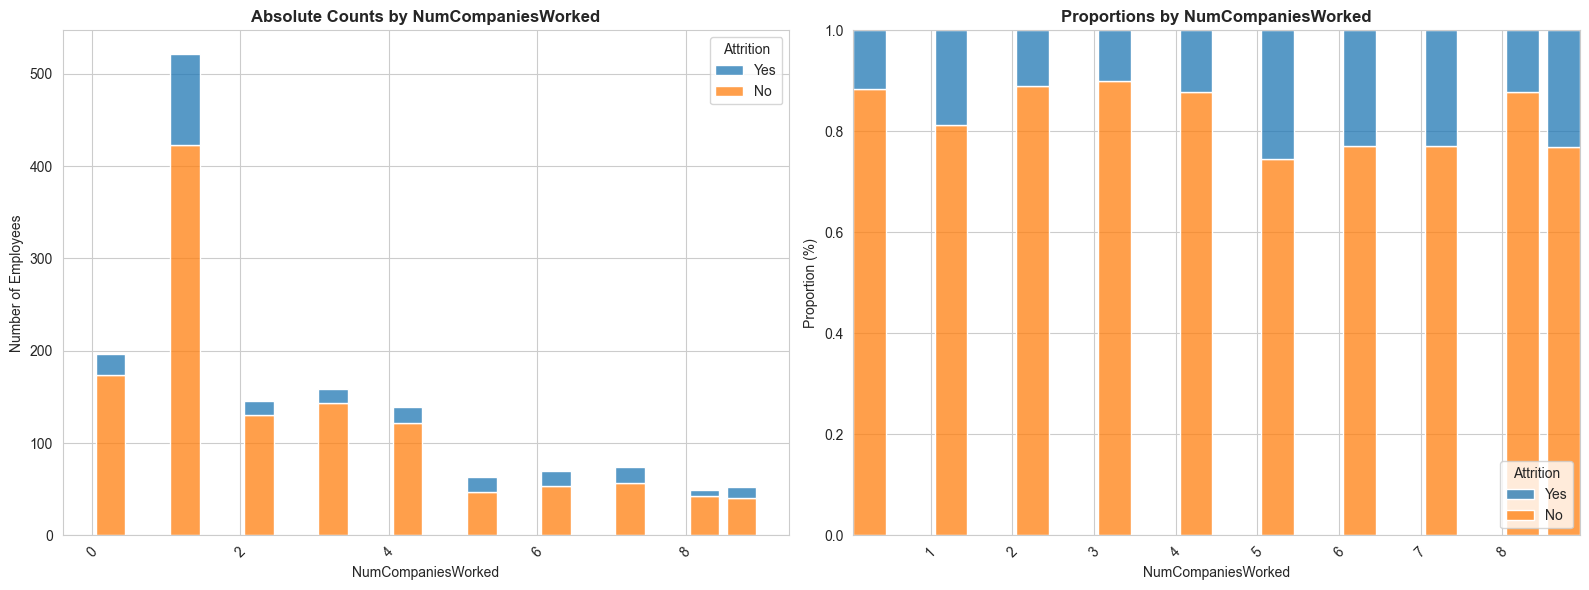

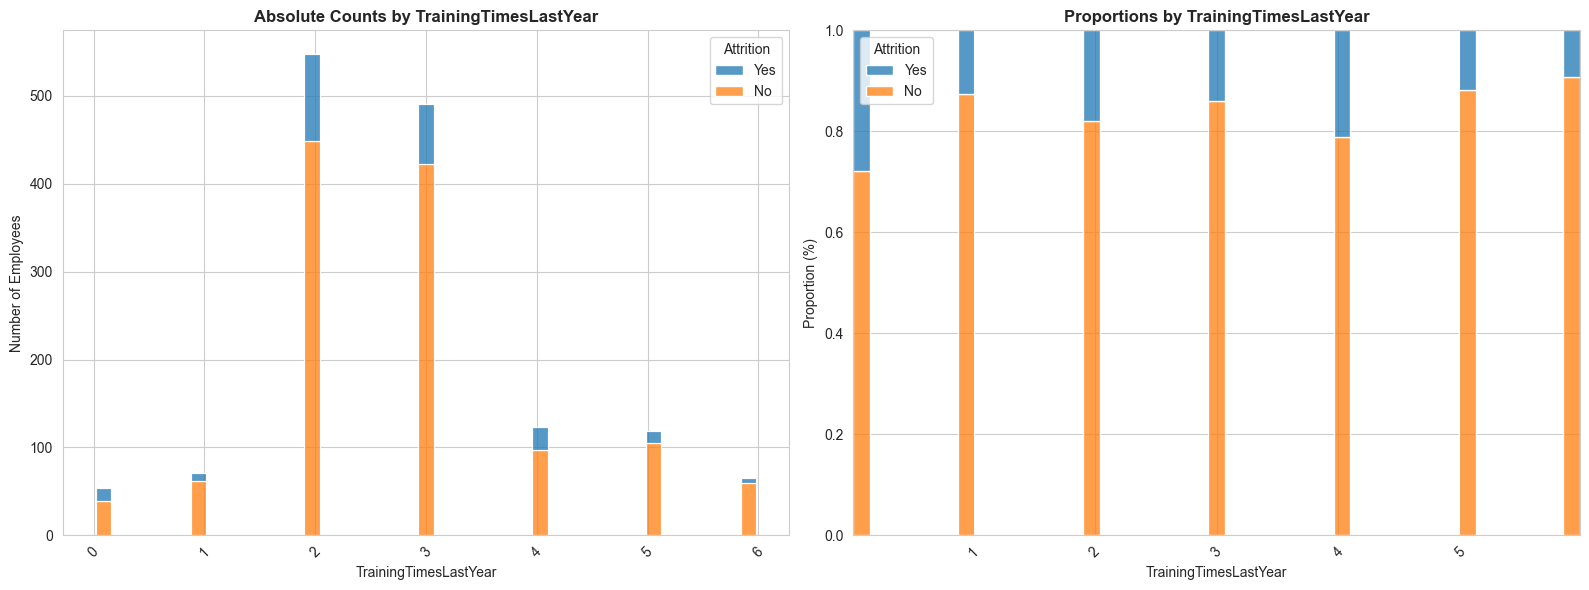

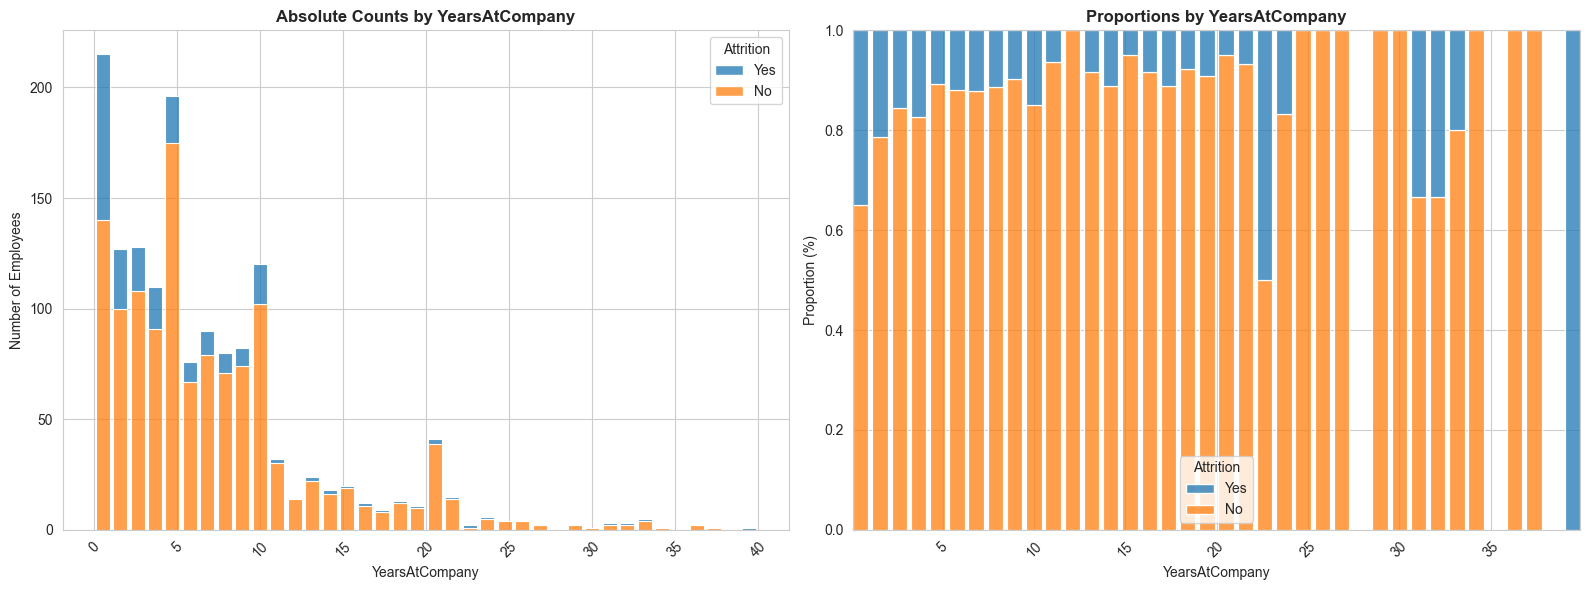

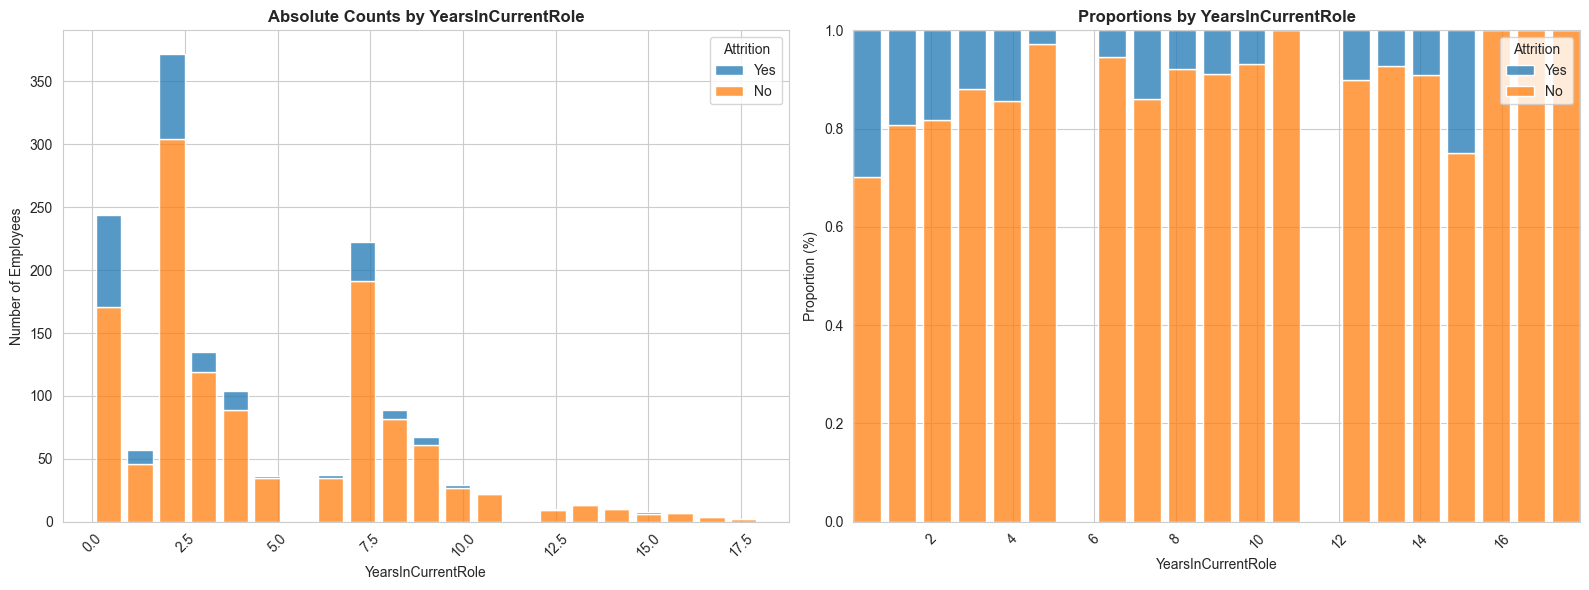

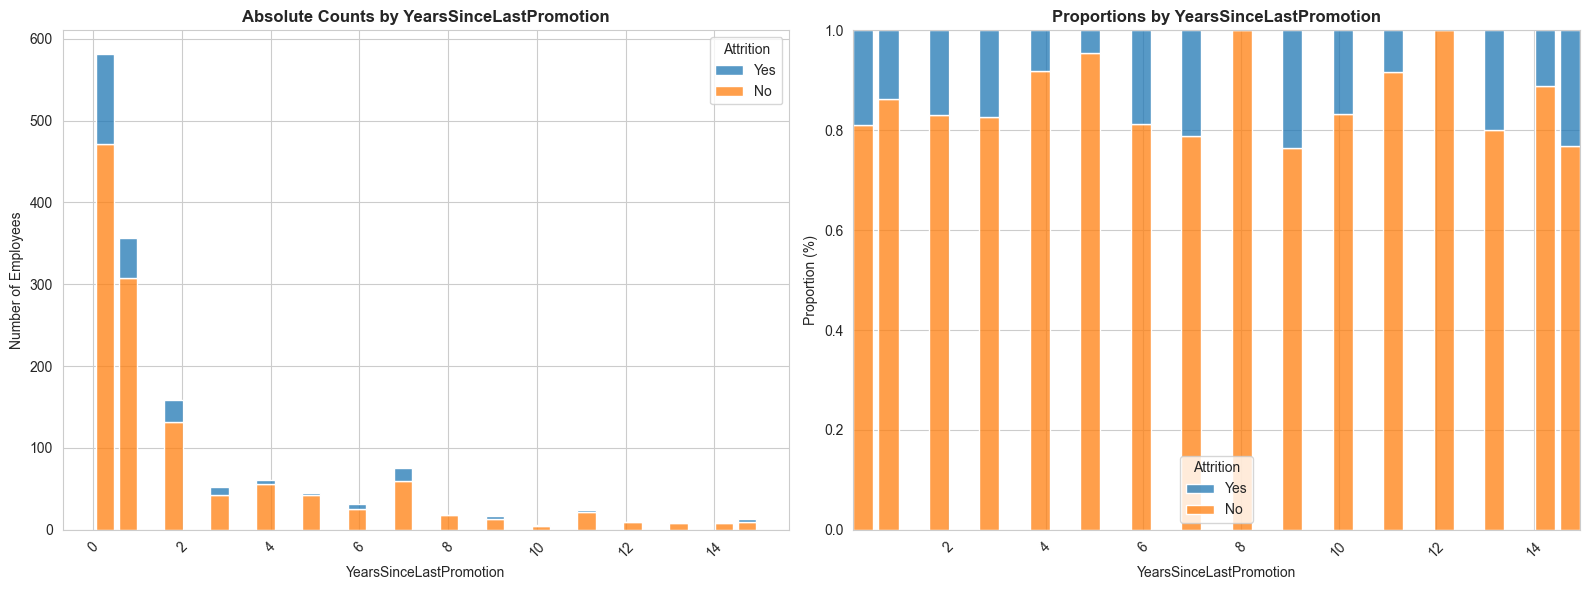

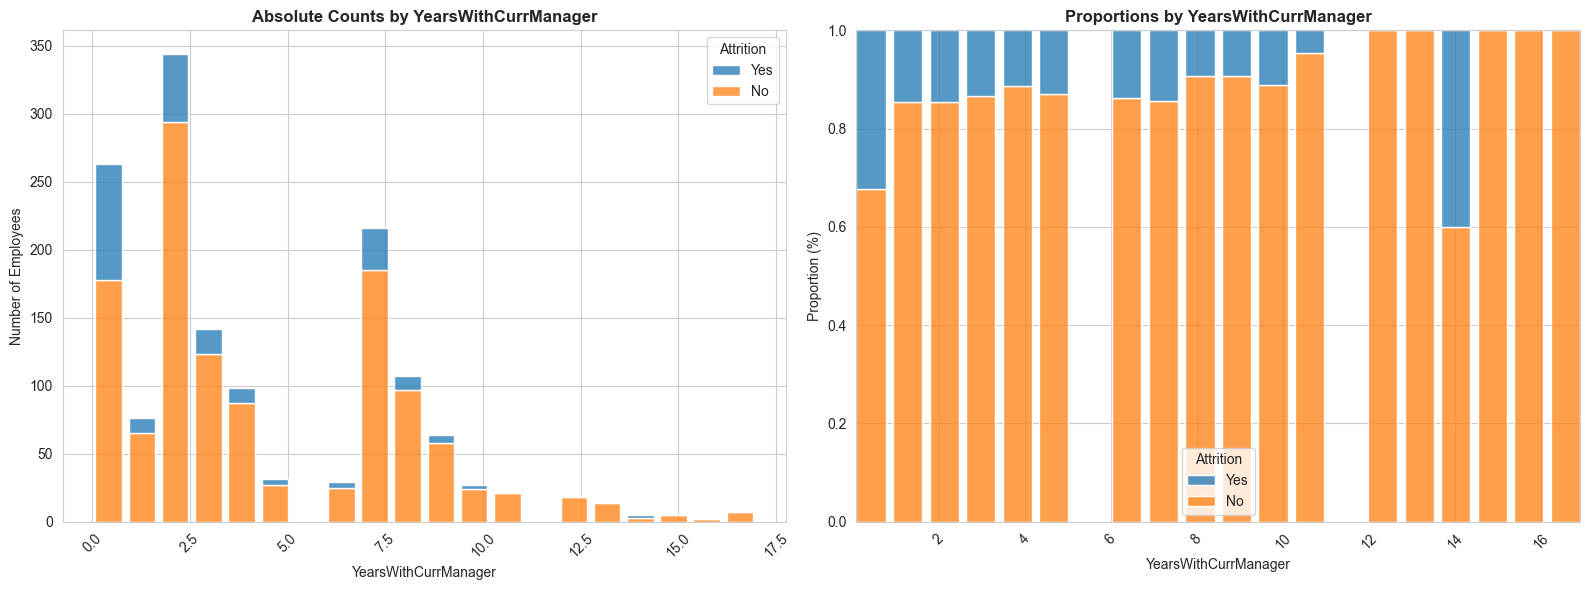

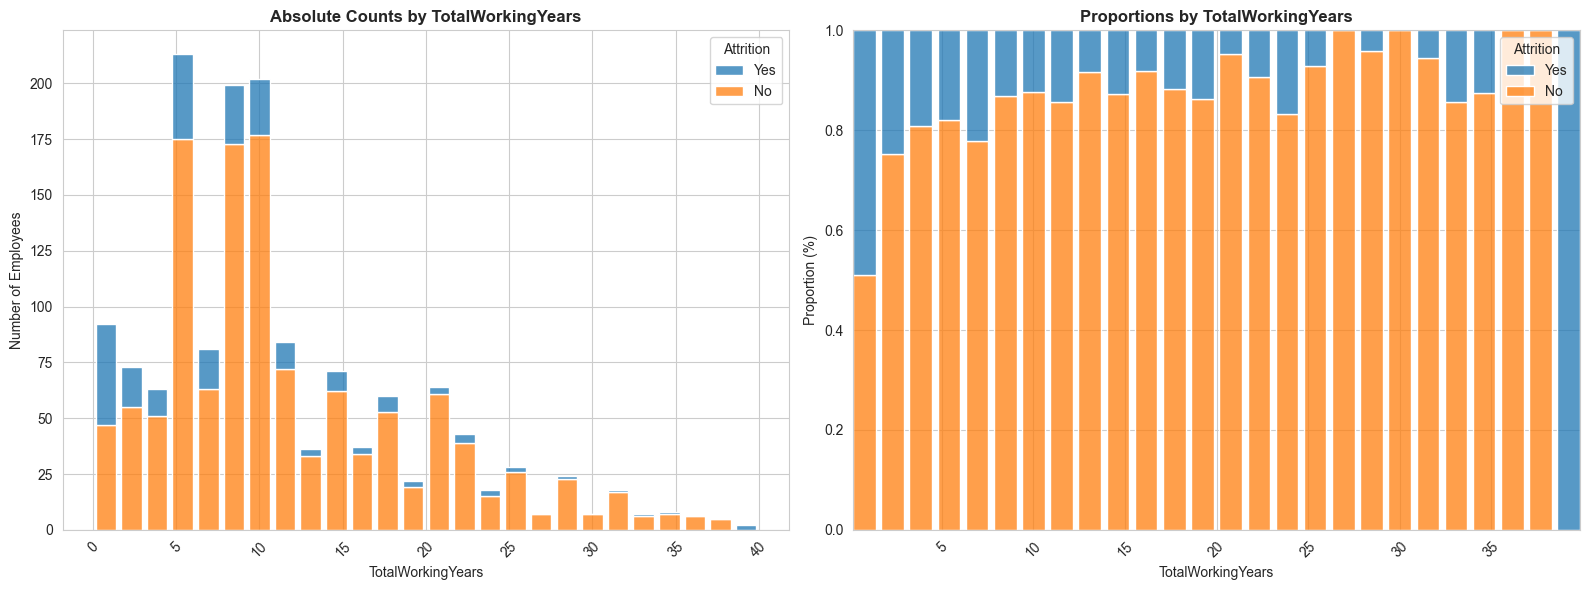

In [8]:
import seaborn as sb

#bar charts for bivarate analysis
def bivarateBarCharts(dataset, index_columns, target_column):
    for index_col in dataset[index_columns]:

        if index_col != target_column:
            # figure creation with 2 plots next to each other (1 row with 2 cols per index column)
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            sb.histplot(
                data=dataset,
                x=dataset[index_col],
                hue=dataset[target_column],
                multiple="stack",
                shrink=0.8,
                ax=axes[0] # left alignment
            )
            axes[0].set_title(f"Absolute Counts by {index_col}", fontsize=12, fontweight='bold')
            axes[0].set_ylabel("Number of Employees")
            axes[0].tick_params(axis='x', rotation=45)

            sb.histplot(
                data=dataset,
                x=dataset[index_col],
                hue=dataset[target_column],
                multiple="fill",
                shrink=0.8,
                ax=axes[1] # right alignment
            )
            axes[1].set_title(f"Proportions by {index_col}", fontsize=12, fontweight='bold')
            axes[1].set_ylabel("Proportion (%)")
            axes[1].tick_params(axis='x', rotation=45)
            plt.tight_layout()
            plt.show()

bivarateBarCharts(ibm_ds, categorical_columns+numerical_columns, 'Attrition')

In [9]:
#correlation heatmap of values, interested on Attrition correlation mostly.

### COULD POTENTIALLY BE REMOVED

#one-hot encoding


# print(ibm_ds_enc.info())

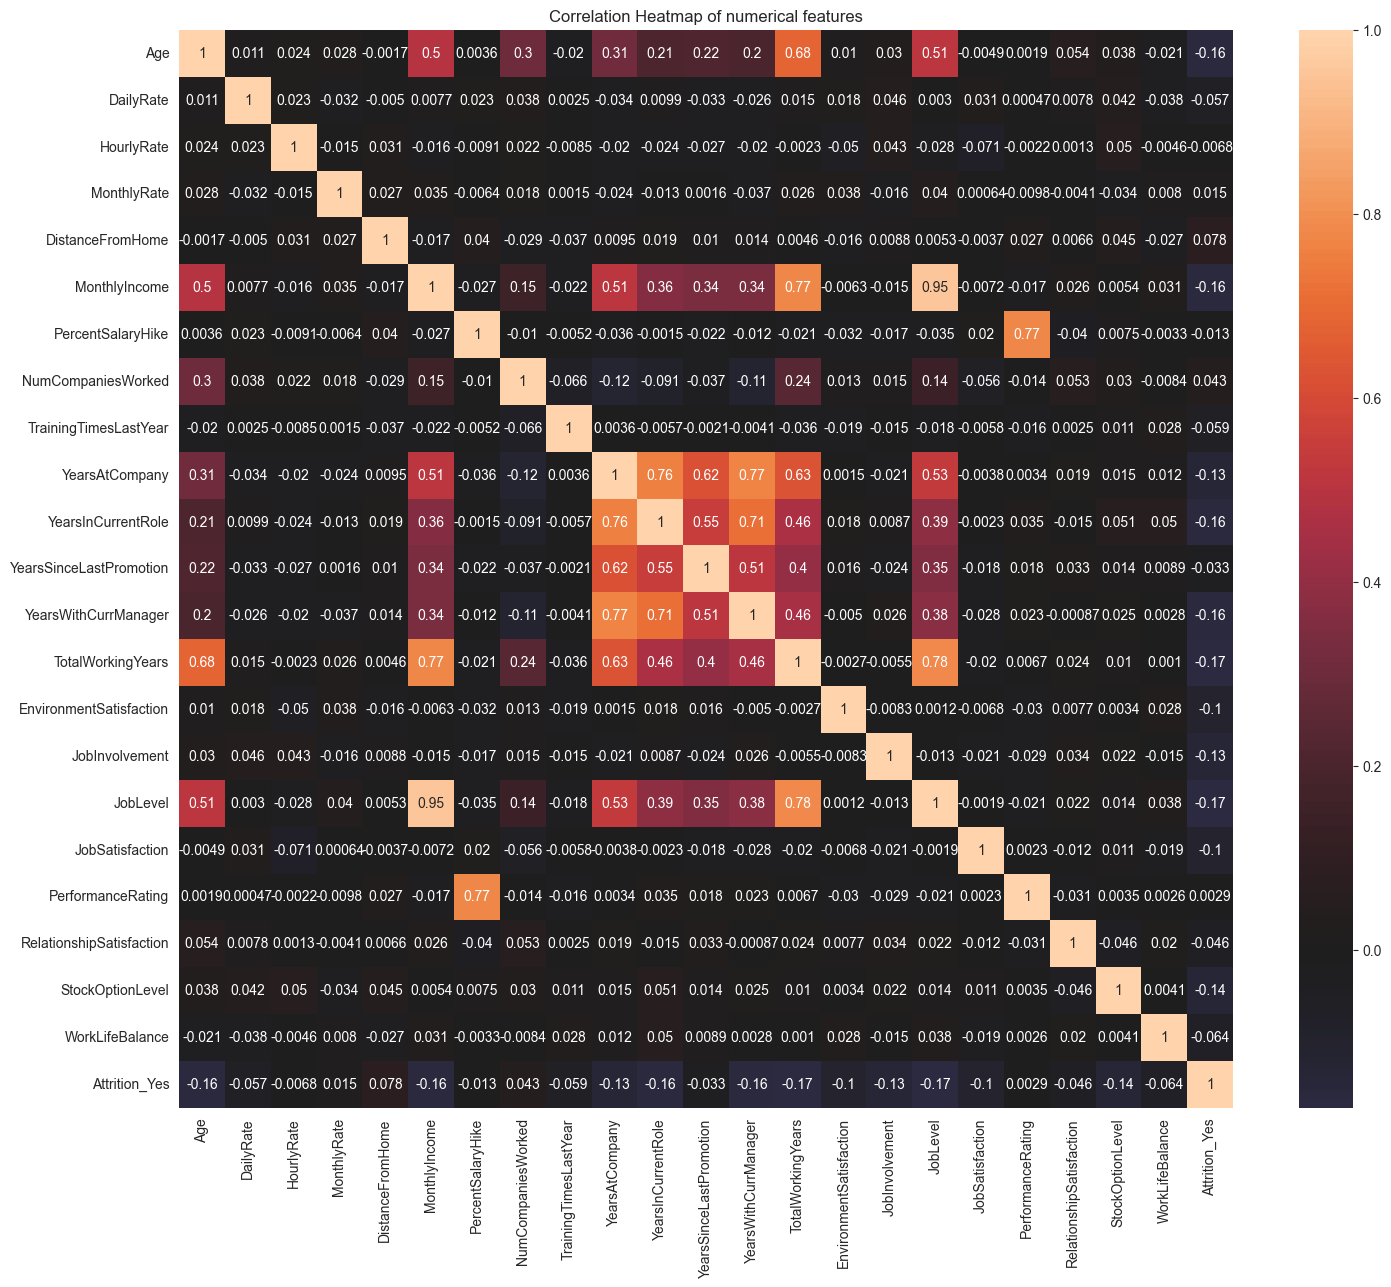

In [10]:
ibm_ds_enc = pd.get_dummies(ibm_ds, columns=[
    # 'BusinessTravel',
    # 'Department',
    # 'EducationField',
    # 'JobRole',
    # 'MaritalStatus',
    # 'Education',
    # 'Gender',
    # 'OverTime',
    'Attrition'
], drop_first=True)

corr_matrix = ibm_ds_enc[numerical_columns + turn_to_numeric_list + ['Attrition_Yes']].corr()
plt.figure(figsize=(17,14))
sb.heatmap(corr_matrix, annot=True,  center= 0)
plt.title("Correlation Heatmap of numerical features")
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, RocCurveDisplay
# convinient function to test a model

#a list to save the AUC results of every classification algorithm
classification_results = []

#creating ROC Curve function and dictionary to keep track of the results
def show_roc_curve (x_tst, y_tst, y_prob, model_recieved, model_title):
    auc_score = roc_auc_score(y_tst, y_prob)
    print(f"ROC AUC Score: {auc_score:.4f}")

    #preparation for visualization of roc curve
    fig, ax = plt.subplots(figsize=(8,6))
    RocCurveDisplay.from_estimator(
        estimator=model_recieved,
        X=x_tst,
        y=y_tst,
        ax=ax,
        name=model_title,
        color='darkorange',
        linewidth=2
    )
    ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random Guess (AUC = 0.50)")
    ax.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=14, fontweight='bold')
    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.show()

    #save results to the classification_results list to compare later
    classification_results.append({"model": model_title, "auc": auc_score})

def test_model(model_used, x_tst, y_tst, title = 'Model Tested'):
    #predictions, containing either True or false
    y_prob = model_used.predict(x_tst)

    print(title)
    print('Accuracy:', accuracy_score(y_tst, y_prob))
    print("                        Classification Report \n",classification_report(y_tst, y_prob))
    print("Confusion Matrix: \n",confusion_matrix(y_tst, y_prob))
    print("="*60)

    #probability from test set
    y_pred_proba = model_used.predict_proba(x_tst)[:, 1] #taking only second column, containing the predicted probability

    show_roc_curve(x_tst, y_tst, y_pred_proba, model_used, title)

    # Sensitivity (recall of True cases - churn = Yes), Specificity (recall of False cases - churn = No) ,Precision, type I error (false positives) and type II error (false negatives) are shown in the classification report

Logistic Regression
Accuracy: 0.8877551020408163
                        Classification Report 
               precision    recall  f1-score   support

       False       0.92      0.95      0.94       255
        True       0.59      0.49      0.54        39

    accuracy                           0.89       294
   macro avg       0.76      0.72      0.74       294
weighted avg       0.88      0.89      0.88       294

Confusion Matrix: 
 [[242  13]
 [ 20  19]]
ROC AUC Score: 0.8271


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


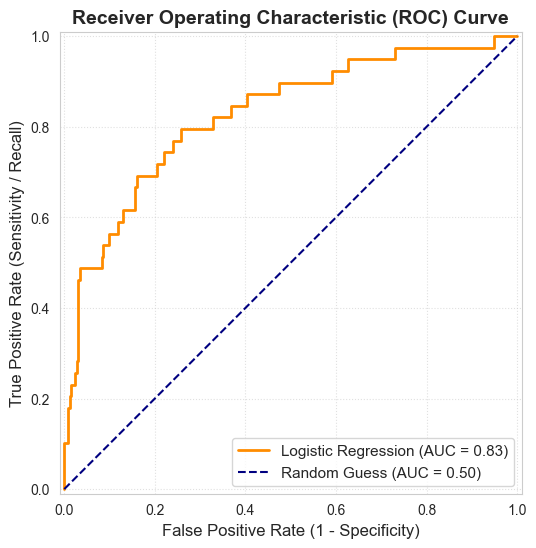

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

x_categorical_columns = [
                'BusinessTravel',
                'Department',
                'EducationField',
                'Gender',
                'JobRole',
                'MaritalStatus',
                'OverTime',
                'Education',
                'EnvironmentSatisfaction',
                'JobInvolvement',
                'JobSatisfaction',
                'PerformanceRating',
                'RelationshipSatisfaction',
                'WorkLifeBalance',
                'StockOptionLevel',
                'JobLevel'
]

#applying one hot encoding with minimum frequency to help with redundant dimensions
ohe = OneHotEncoder(min_frequency=0.05, handle_unknown='infrequent_if_exist', sparse_output=False)

x = ibm_ds.drop(['Attrition'], axis=1)
#turning Attrition column to Boolean type
encoding_attrition = pd.get_dummies(ibm_ds,columns=['Attrition'], drop_first=True)
y = encoding_attrition['Attrition_Yes']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

#scaler initialization
scaler = StandardScaler()

#applying one-hot encoding using x_categorical_columns list
x_train_enc = ohe.fit_transform(x_train[x_categorical_columns])
x_test_enc = ohe.transform(x_test[x_categorical_columns])

#scaling the numerical columns for easier processing
x_train_scaled = scaler.fit_transform(x_train [numerical_columns + turn_to_numeric_list])
x_test_scaled = scaler.transform(x_test [numerical_columns + turn_to_numeric_list])

x_train = np.hstack((x_train_enc, x_train_scaled))
x_test = np.hstack((x_test_enc, x_test_scaled))

lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_train, y_train)

test_model(lr_model,x_test,y_test, 'Logistic Regression')

Random Forest
Accuracy: 0.8741496598639455
                        Classification Report 
               precision    recall  f1-score   support

       False       0.88      0.99      0.93       255
        True       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294

Confusion Matrix: 
 [[253   2]
 [ 35   4]]
ROC AUC Score: 0.7774


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


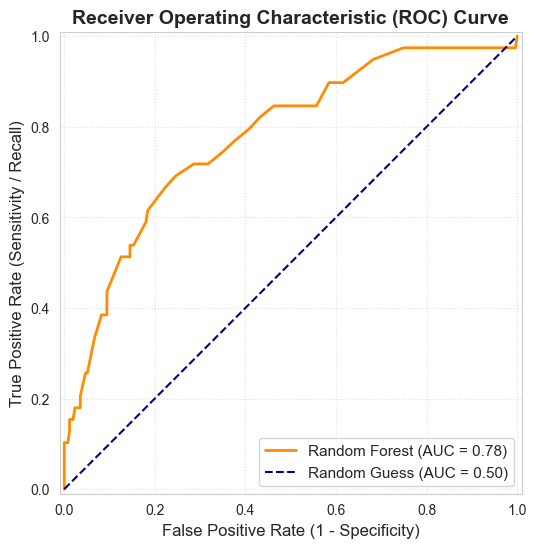

In [13]:
#testing random forest
from sklearn.ensemble import RandomForestClassifier

#2 tests for random forest, one for One-Hot encoded categorical values and one for non encoded.

#random forest model with default parameters for now, will be optimized later
random_forest_model_enc = RandomForestClassifier()
random_forest_model_enc.fit(x_train, y_train)

test_model(random_forest_model_enc, x_test, y_test, 'Random Forest')

XGBoost
Accuracy: 0.8945578231292517
                        Classification Report 
               precision    recall  f1-score   support

       False       0.90      0.99      0.94       255
        True       0.83      0.26      0.39        39

    accuracy                           0.89       294
   macro avg       0.87      0.62      0.67       294
weighted avg       0.89      0.89      0.87       294

Confusion Matrix: 
 [[253   2]
 [ 29  10]]
ROC AUC Score: 0.7608


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


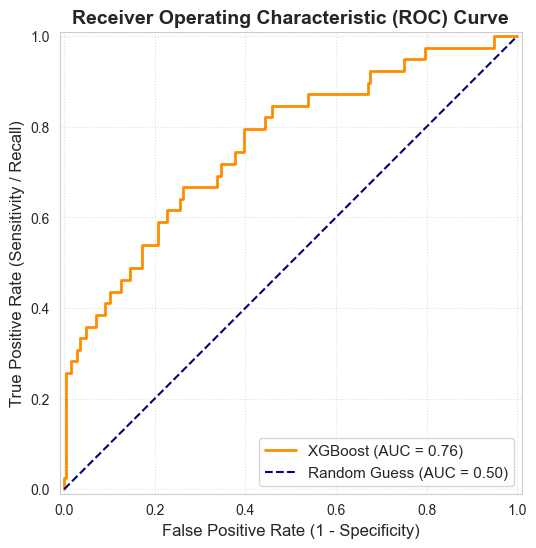

In [14]:
#testing default XGBoost for classification. Will be further optimized later
from xgboost import XGBClassifier

#Since the dataset is imbalanced, the ratio of Yes and No on the Attrition column will be calculated to be passed on the scale_pos_weight parameter
negatives = (y_train == 0).sum()
positives = (y_train ==1).sum()
ratio = 0
if positives > 0: ratio = positives/(positives+negatives)

xgb_model = XGBClassifier(scale_pos_weight=ratio,random_state=42)
xgb_model.fit(x_train, y_train)
test_model(xgb_model, x_test, y_test, 'XGBoost')

[LightGBM] [Info] Number of positive: 198, number of negative: 978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1238
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM
Accuracy: 0.8537414965986394
                        Classification Report 
               precision    recall  f1-score   support

       False       0.90      0.94      0.92       255
        True       0.43      0.31      0.36        39

    accuracy                           0.85       294
   macro avg       0.66      0.62      0.64       294
weighted avg       0.84      0.85      0.84       294

Confusion Matrix: 
 [[239  16]
 [ 27

C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


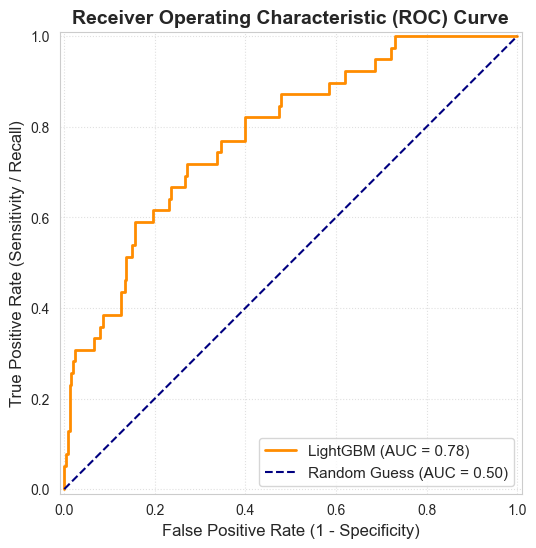

In [15]:
#testing default LightGBM for classification. Will be further optimized later
from lightgbm import LGBMClassifier

#inclusion of class_weight = 'balanced' to handle the imbalance present on Attrition level. SMOTE will be skipped for that reason.
lgbm_model = LGBMClassifier(class_weight='balanced',random_state=42)
lgbm_model.fit(x_train, y_train)
test_model(lgbm_model, x_test, y_test, 'LightGBM')

SVM
Accuracy: 0.8877551020408163
                        Classification Report 
               precision    recall  f1-score   support

       False       0.89      1.00      0.94       255
        True       1.00      0.15      0.27        39

    accuracy                           0.89       294
   macro avg       0.94      0.58      0.60       294
weighted avg       0.90      0.89      0.85       294

Confusion Matrix: 
 [[255   0]
 [ 33   6]]
ROC AUC Score: 0.8538


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


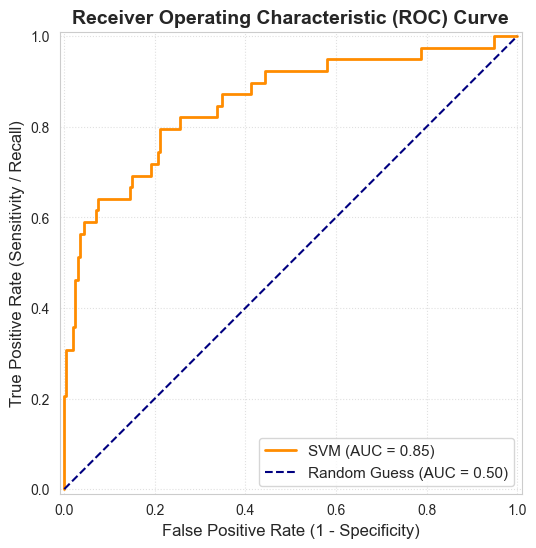

In [16]:
from sklearn.svm import SVC

#default svm model for classification. Will be further optimized later
svm_model = SVC(probability=True #so that the funtion predict_proba is available (for the test_model function)
                , random_state=42)
svm_model.fit(x_train, y_train)
test_model(svm_model, x_test, y_test, 'SVM')

Logistic Regression SMOTE
Accuracy: 0.7619047619047619
                        Classification Report 
               precision    recall  f1-score   support

       False       0.94      0.78      0.85       255
        True       0.31      0.67      0.43        39

    accuracy                           0.76       294
   macro avg       0.63      0.72      0.64       294
weighted avg       0.86      0.76      0.79       294

Confusion Matrix: 
 [[198  57]
 [ 13  26]]
ROC AUC Score: 0.7865


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


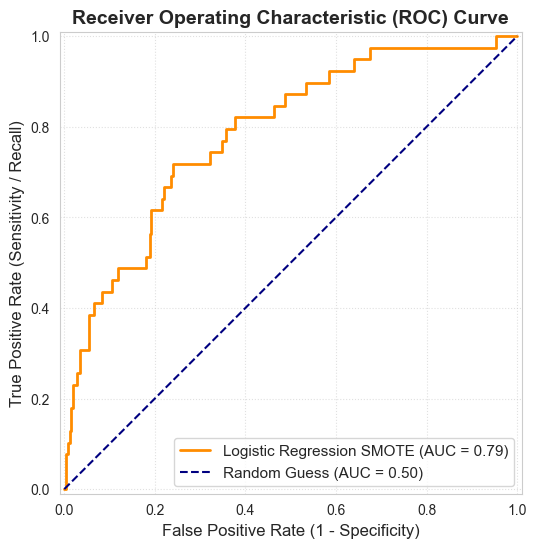

Random Forest SMOTE
Accuracy: 0.8809523809523809
                        Classification Report 
               precision    recall  f1-score   support

       False       0.89      0.98      0.93       255
        True       0.64      0.23      0.34        39

    accuracy                           0.88       294
   macro avg       0.77      0.61      0.64       294
weighted avg       0.86      0.88      0.86       294

Confusion Matrix: 
 [[250   5]
 [ 30   9]]
ROC AUC Score: 0.7670


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


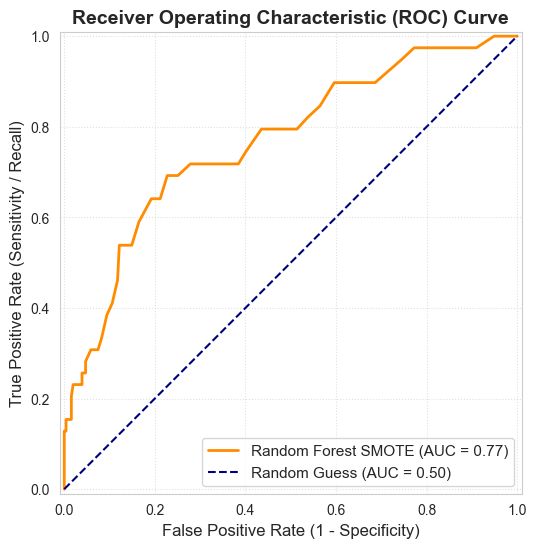

SVM SMOTE
Accuracy: 0.8877551020408163
                        Classification Report 
               precision    recall  f1-score   support

       False       0.92      0.95      0.94       255
        True       0.60      0.46      0.52        39

    accuracy                           0.89       294
   macro avg       0.76      0.71      0.73       294
weighted avg       0.88      0.89      0.88       294

Confusion Matrix: 
 [[243  12]
 [ 21  18]]
ROC AUC Score: 0.8067


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


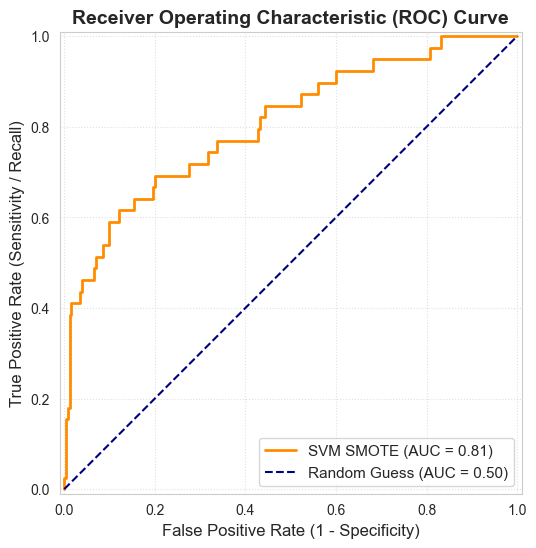

In [17]:
#application of SMOTE to handle the imbalance of Attrition
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

#reapplying logistic regression
lr_model_sm = LogisticRegression(random_state=42)
lr_model_sm.fit(x_train_resampled, y_train_resampled)

test_model(lr_model_sm,  x_test, y_test, 'Logistic Regression SMOTE')

random_forest_model_sm = RandomForestClassifier()
random_forest_model_sm.fit(x_train_resampled, y_train_resampled)

test_model(random_forest_model_sm, x_test, y_test, 'Random Forest SMOTE')

svm_model_sm = SVC(probability=True #so that the funtion predict_proba is available (for the test_model function)
                , random_state=42)
svm_model_sm.fit(x_train_resampled, y_train_resampled)
test_model(svm_model_sm, x_test, y_test, 'SVM SMOTE')


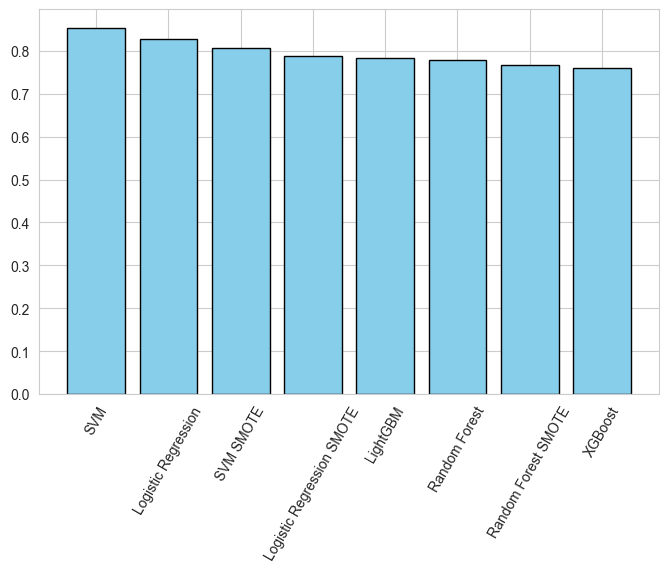

In [18]:
#results from all the classifications done thus far

#making it a DF for easier visualizations
class_res_df = pd.DataFrame(classification_results)
class_res_df.sort_values(by=['auc'], ascending=False, inplace=True)

plt.figure(figsize=(8,5))
plt.bar(class_res_df['model'], class_res_df['auc'], color = 'skyblue', edgecolor="black")
plt.xticks(rotation=60)
plt.show()

In [19]:
from skopt.space import Real,Integer, Categorical

#Creatiin of model configuration dictionary. Preparing for Bayesian Search
models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'space': {
            'C': Real(0.003, 1e2, prior='log-uniform'),
            'penalty': Categorical(['l1', 'l2'])
        },
        'train_data': x_train,
        'test_data': x_test
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'space': {
            'n_estimators': Integer(50, 400),
            'max_depth': Integer(3, 15),
            'min_samples_split': Integer(2, 10)
        },
        'train_data': x_train,
        'test_data': x_test
    },
    'SVM':{
        'model': SVC(probability=True, kernel='linear', random_state=42),
        'space': {
            'C': Real(0.01,50, prior='log-uniform'),
            'gamma': Real(0.0001,0.1, prior='log-uniform'),
            'kernel': Categorical(['rbf'])
        },
        'train_data': x_train,
        'test_data': x_test
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'space': {
            'n_estimators': Integer(50, 400),
            'max_depth': Integer(3, 10),
            'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
            'scale_pos_weight': Real(1.0, 6.0)
        },
        'train_data': x_train,
        'test_data': x_test
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
        'space': {
            'n_estimators': Integer(50, 400),
            'max_depth': Integer(3, 12),
            'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
            'num_leaves': Integer(15, 63)
        },
        'train_data': x_train,
        'test_data': x_test
    }
}

In [21]:
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold

opt_results = []

#cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# print(models_config.items())
for model_name, config in models_config.items():
    print(f"Optimization for {model_name}: ")

    bs = BayesSearchCV(
        estimator=config['model'],
        search_spaces=config['space'],
        n_iter=15,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        verbose=0,
        random_state=42
    )
    bs.fit(config['train_data'], y_train)
    #saving best score
    best_cv_score = bs.best_score_
    best_model = bs.best_estimator_

    y_prb = best_model.predict_proba(config['test_data'])[:, 1]
    test_score = roc_auc_score(y_test, y_prb)

    print(f"Best CV ROC-AUC: {best_cv_score:.4f} | Test ROC-AUC: {test_score:.4f}")

    opt_results.append({
        'Model': model_name,
        'Best CV ROC-AUC': round(best_cv_score, 4),
        'Test ROC-AUC': round(test_score, 4),
        'Best Params': bs.best_params_
    })

Optimization for Logistic Regression: 


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best CV ROC-AUC: 0.8639 | Test ROC-AUC: 0.8302
Optimization for Random Forest: 
Best CV ROC-AUC: 0.8341 | Test ROC-AUC: 0.7617
Optimization for SVM: 
Best CV ROC-AUC: 0.8628 | Test ROC-AUC: 0.8424
Optimization for XGBoost: 
Best CV ROC-AUC: 0.8150 | Test ROC-AUC: 0.7814
Optimization for LightGBM: 
Best CV ROC-AUC: 0.8190 | Test ROC-AUC: 0.7756


C:\Users\chris\PycharmProjects\Thesis_part_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [64]:
opt_results_df = pd.DataFrame(opt_results)

print('Initial Model results before Bayesian Search\n')
for value in classification_results:
    print(f'Model: {value['model']}\nAUC:\t{value['auc']}')
# print(opt_results_df)
print('\nFinal Model results after Bayesian Search (BENCHMARK)\n')
print(opt_results_df[['Model', 'Best CV ROC-AUC', 'Test ROC-AUC']].to_string(index=False))

print("Best Hyperparameters per model:")
for i in range(len(opt_results_df)):
    print(f'Model: {opt_results_df['Model'][i]}')
    # for value in opt_results_df['Best Params'][i]:
    #     print(f'{value}')
    print(opt_results_df['Best Params'][i])

Initial Model results before Bayesian Search

Model: Logistic Regression
AUC:	0.8271493212669684
Model: Random Forest
AUC:	0.7773755656108597
Model: XGBoost
AUC:	0.7607843137254902
Model: LightGBM
AUC:	0.7832076420311714
Model: SVM
AUC:	0.853795877325289
Model: Logistic Regression SMOTE
AUC:	0.7865258924082454
Model: Random Forest SMOTE
AUC:	0.7669683257918553
Model: SVM SMOTE
AUC:	0.8067370537958773

Final Model results after Bayesian Search (BENCHMARK)

              Model  Best CV ROC-AUC  Test ROC-AUC
Logistic Regression           0.8639        0.8302
      Random Forest           0.8341        0.7617
                SVM           0.8628        0.8424
            XGBoost           0.8150        0.7814
           LightGBM           0.8190        0.7756
Best Hyperparameters per model:
Model: Logistic Regression
OrderedDict({'C': 0.3083505801105222, 'penalty': 'l2'})
Model: Random Forest
OrderedDict({'max_depth': 13, 'min_samples_split': 3, 'n_estimators': 259})
Model: SVM
OrderedDict

In [71]:
#getting all the column names to find out about feature imporatance per model
all_columns = list(ohe.get_feature_names_out(x_categorical_columns))+ list(numerical_columns+turn_to_numeric_list)

#printint columns and their importance based on the model's saved data
for i in range(len(random_forest_model_enc.feature_importances_)):
    print(f"Column: {all_columns[i]},\nImportance: {random_forest_model_enc.feature_importances_[i]}\n")

print('-+'*50)

#same for xgboost
for i in range(len(xgb_model.feature_importances_)):
    print(f"Column: {all_columns[i]},\nImportance: {xgb_model.feature_importances_[i]}\n")

#getting the coefficiencies for the trained Logistic Regression model
coefficients_lr = lr_model.coef_[0]

log_reg_df = pd.DataFrame({
    'Feature': all_columns,
    'Coefficient': coefficients_lr
}).sort_values(by='Coefficient', ascending=False)
#printing the top 5 features that increase Attrition
print(log_reg_df.head())

Column: BusinessTravel_Non-Travel,
Importance: 0.0034865922040048106

Column: BusinessTravel_Travel_Frequently,
Importance: 0.010843419739559622

Column: BusinessTravel_Travel_Rarely,
Importance: 0.0066223773961269425

Column: Department_Research & Development,
Importance: 0.0069784388145834545

Column: Department_Sales,
Importance: 0.008129591552933196

Column: Department_infrequent_sklearn,
Importance: 0.0017033100619630588

Column: EducationField_Life Sciences,
Importance: 0.0060516664322048195

Column: EducationField_Marketing,
Importance: 0.00618302701628561

Column: EducationField_Medical,
Importance: 0.006710592045304265

Column: EducationField_Other,
Importance: 0.002623377146030898

Column: EducationField_Technical Degree,
Importance: 0.006048843740583851

Column: EducationField_infrequent_sklearn,
Importance: 0.0019149656534151228

Column: Gender_Female,
Importance: 0.0058667202644323724

Column: Gender_Male,
Importance: 0.006168326160023035

Column: JobRole_Healthcare Repres